In [ ]:
import pandas as pd

# ─────────────────────────────────────────────────────────────
# [FIX] DATA LOADING — two options, uncomment the one you need
# ─────────────────────────────────────────────────────────────

# OPTION A: Upload files manually (click the folder icon on the
#           left → upload posts.csv and reddit_comments_clean.csv)
#           then run this cell — /content/ is Colab's default folder.
posts    = pd.read_csv("/content/posts.csv")
comments = pd.read_csv("/content/reddit_comments_clean.csv")

# OPTION B: Mount Google Drive and load from there.
#           Uncomment the four lines below and update the paths.
# from google.colab import drive
# drive.mount('/content/drive')
# posts    = pd.read_csv("/content/drive/MyDrive/your_folder/posts.csv")
# comments = pd.read_csv("/content/drive/MyDrive/your_folder/reddit_comments_clean.csv")

print("posts shape:",    posts.shape)
print("comments shape:", comments.shape)


In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)


RENAMING COLUMNS

In [ ]:
posts = posts.rename(columns={"id": "post_id", "text": "post_text"})
comments = comments.rename(columns={"text": "comment_text"})

FILTER OUT EMPTY TEXTS

In [ ]:
posts["post_text"].isna().sum(), comments["comment_text"].isna().sum()
comments = comments.dropna(subset=["comment_text"])
posts["post_text"] = posts["post_text"].fillna("[EXTERNAL_LINK_OR_NO_TEXT]")


sort everything by time

In [ ]:
posts = posts.sort_values("timestamp")
comments = comments.sort_values("timestamp")


grouping commnets by post


In [ ]:
grouped_comments = comments.groupby("post_id")


BUILDING NARRATIVE UNITS EXPLICITLY

In [ ]:
narrative_units = []

for _, post in posts.iterrows():
    pid = post["post_id"]

    post_text = post["post_text"]
    post_time = post["timestamp"]

    if pid in grouped_comments.groups:
        comment_texts = grouped_comments.get_group(pid)["comment_text"].tolist()
    else:
        comment_texts = []

    narrative_units.append({
        "post_id": pid,
        "post_text": post_text,
        "post_timestamp": post_time,
        "comments": comment_texts,
        "num_comments": len(comment_texts)
    })


CONVERTING NARRATIVE UNITS TO DATAFRAME


In [ ]:
narratives_df = pd.DataFrame(narrative_units)
narratives_df.head()



post_id  \
0  12vyubs   
1  132oa6r   
2  134393k   
3  1345vai   
4  1347y8a   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    post_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

importing transformer for sentence embedding


In [ ]:
!pip install sentence-transformers nltk


note: here nltk is a natural language toolkit , will used it for sentence splitting.

punkt is a sentence tokenizer(i.e tool that splits text into meaningful units)

In [ ]:
from sentence_transformers import SentenceTransformer
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

LOAD AN EMBEEDDIG MODEL

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

EXTRACTING SENTENCES FROM NARRATIVE UNITS

sentence split function


In [ ]:
from nltk.tokenize import sent_tokenize

def extract_sentences(text):
    if not isinstance(text, str):
        return []
    return sent_tokenize(text)


build a sentence level dataset

In [ ]:
sentence_records = []

# Create lookup for post timestamps
post_time_lookup = posts.set_index("post_id")["timestamp"].to_dict()

for _, row in narratives_df.iterrows():
    post_id = row["post_id"]

    # --- Post sentences ---
    post_sentences = extract_sentences(row["post_text"])
    post_timestamp = post_time_lookup.get(post_id)

    for s in post_sentences:
        sentence_records.append({
            "post_id": post_id,
            "source": "post",
            "sentence": s,
            "timestamp": post_timestamp
        })

    # --- Comment sentences ---
    post_comments = comments[comments["post_id"] == post_id]

    for _, c in post_comments.iterrows():
        comment_sentences = extract_sentences(c["comment_text"])
        comment_timestamp = c["timestamp"]

        for s in comment_sentences:
            sentence_records.append({
                "post_id": post_id,
                "source": "comment",
                "sentence": s,
                "timestamp": comment_timestamp
            })


In [ ]:
sentences_df = pd.DataFrame(sentence_records)
sentences_df.head()


,post_id,source,sentence,timestamp
0,12vyubs,post,[EXTERNAL_LINK_OR_NO_TEXT],2023-04-23 07:45:12
1,12vyubs,comment,Holy land!,2023-04-23 07:54:02
2,12vyubs,comment,Checkmate,2023-04-23 08:37:45
3,12vyubs,comment,Ke2,2023-04-23 09:33:57
4,12vyubs,comment,Wet simple… nuke it all.,2023-04-23 11:16:41


In [ ]:
# SAFE RESET — clears only downstream variables, NOT sentences_df

for var in [
    "X_reduced",
    "clustered_sentences_df",
    "centroids_df",
    "narrative_map",
    "narrative_stats",
    "qualified_narratives"
]:
    if var in globals():
        del globals()[var]

print("Reset done. Raw sentences preserved.")



Reset done. Raw sentences preserved.


(issue fixing : sentence level duplication)

topic+Sentence Quality Filter

In [ ]:
import re

KEYWORDS = [
    "israel", "palestine", "gaza", "hamas", "idf",
    "ceasefire", "hostage", "prisoner", "genocide",
    "occupation", "bomb", "strike", "military",
    "zionist", "settlement", "netanyahu", "biden",
    "palestinian", "israeli"
]

def is_valid_sentence(s):
    s = s.strip().lower()

    if len(s) < 40:
        return False
    if len(s.split()) < 7:
        return False

    if not any(k in s for k in KEYWORDS):
        return False

    if re.search(r"\b(lol|lmao|wtf|stan|damn)\b", s):
        return False

    return True

# Deduplicate + filter
sentences_df = sentences_df.drop_duplicates(
    subset=["sentence", "timestamp", "post_id", "source"]
)

sentences_df = sentences_df[
    sentences_df["sentence"].apply(is_valid_sentence)
].reset_index(drop=True)

print("Clean sentences:", len(sentences_df))
sentences_df.sample(10)


Clean sentences: 19995


,post_id,source,sentence,timestamp
6840,17prmvh,comment,"Do you have any suggestions then, on how the Israeli state could respond to something like that in order to neutralize Hamas which is hiding inside Gaza?",2023-11-07 12:43:31
18389,1bzg5fl,comment,Israel is holding on to his body until his term is completed - even in death they won’t unshackle him.,2024-04-09 01:49:27
11246,18rgdu8,comment,"In the wise words of Noura Erakat, ""Israel does not have a Hamas problem.",2023-12-26 21:03:00
17856,1bw2ulk,comment,You cannot 'abolish Zionism' without dismantling the state of Israel.,2024-04-05 03:00:59
4024,17da0l8,comment,People are being doxxed for supporting people who are severely denied of their right to live is NOT ok. Why can’t the people who blindly side with Israel see this?,2023-10-21 22:02:55
8580,181wa83,comment,"I don't have any questions but welcome to r/Israel sub 💙 i pray everyday that peace between israel, palestine and rest of middle east will be achieved soon.",2023-11-23 09:27:53
11279,18rgdu8,comment,Some violence ensued begun by the group now called the Palestinians.,2023-12-29 05:29:45
18551,1c05f88,comment,If israel was as bad as hamas they would have struck an aid convoy with drone 3 times killing all the aid workers,2024-04-10 04:31:24
987,172w9gt,comment,"I side with Israel because I know I could go to Israel as a gay man, and wouldn't be murdered for how I was born.",2023-10-08 21:36:29
12859,19f3u2c,comment,What's horrible about this propaganda is the very idea that the Palestinians mistreated their own women and must be bombed to free them.,2024-01-25 09:55:37


sanity check (sentence filter)
new issue(1.1:it is removing garbage but not forming semantic clusters

In [ ]:
sentences_df.sample(20)["sentence"]


,sentence
18503,^(Edit: Yes I am aware (and plenty of binational one staters are aware\) that Israel currently has a large minority muslim/druze/christian population with full citizenship.
11955,Zionism is the Jewish belief that there should be a self-governed Jewish state in the region of Judaea (which had been renamed Palestine).
17086,"Israel attacking hospitals, schools, Religious places, women and children in Palestine is a true form of terrorism."
13686,I'm certain that at least one neonazi and one 'decolonialist' have hooked up thanks to the Gaza issue in this months
8807,Biden’s own government has admitted that Israel used the type of bombs that would cause mass civilian casualties instead of the smaller more accurate projectiles.
14953,"Though I’d guess that in his mind, people already know that and he probably thinks pointing out netanyahu’s crimes are redundant."
1194,Sucks to be a Palestinian in Gaza but you can't expect Israel to have open border crossings with a territory ran by a terrorist organization whose stated objective is the destruction of Israel.
2585,"""Israel is a country that is surrounded by these brutal, savage, groups like Hamas and Hezbollah, countries like Iran, often supported by Islamic fundamentalists and anti-Semites around the world."""
1509,"The terrorists have to fucking stop, and if that means IDF members mowing down dipshit terrorists dudes outhere who think they can rape and pillage Israelis at this point they have my fucking blessing"
8768,"Israel on the other hand, has been trying to find a way to live in peace with people who seem to prefer fighting than accepting the current realities on the ground working towards a peaceful coexistence."


GENERATING EMBEDDINGS


In [ ]:
embeddings = model.encode(
    sentences_df["sentence"].tolist(),
    show_progress_bar=True
)
sentences_df["embedding"] = list(embeddings)


Batches:   0%|          | 0/625 [00:00<?, ?it/s]

PHASE 4: NARRATIVE CLUSTERING & EMERGENCE





INSTALLING CLUSTERING ALGO
1. HDBSCAN
2. UMAP



In [ ]:
!pip install hdbscan umap-learn


preparing embeddings for clusterings

In [ ]:

import numpy as np
import hdbscan


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


prepare time + embeddings

In [ ]:
# Ensure timestamp is datetime
sentences_df["timestamp"] = pd.to_datetime(sentences_df["timestamp"])

# Convert embeddings column to NumPy array (once)
X_all = np.vstack(sentences_df["embedding"].values)


dimensionality reduction ONCE

In [ ]:
import umap

reducer = umap.UMAP(
    n_neighbors=8,          # smaller = more local structure
    n_components=50,
    min_dist=0.1,          # encourages separation
    metric="cosine",
    random_state=42
)


X_reduced = reducer.fit_transform(X_all)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


attach reduced embeddings back


In [ ]:
sentences_df["embedding_reduced"] = list(X_reduced)


72-hour sliding windows

In [ ]:
from datetime import timedelta


sentences_df["timestamp"] = pd.to_datetime(sentences_df["timestamp"])

WINDOW_SIZE = timedelta(hours=72)
STEP_SIZE   = timedelta(hours=24)

start_time = sentences_df["timestamp"].min()
end_time   = sentences_df["timestamp"].max()

window_results = []
current_start = start_time

while current_start < end_time:
    current_end = current_start + WINDOW_SIZE

    window_df = sentences_df[
        (sentences_df["timestamp"] >= current_start) &
        (sentences_df["timestamp"] < current_end)
    ]

    if len(window_df) < 80:
        current_start += STEP_SIZE
        continue

    X_window = np.vstack(window_df["embedding_reduced"].values)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=8,
        min_samples=4,
        metric="euclidean",
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(X_window)

    window_df = window_df.copy()
    window_df["cluster"] = labels
    window_df["window_start"] = current_start

    # Remove noise
    window_df = window_df[window_df["cluster"] != -1]

    # Remove tiny clusters
    cluster_sizes = window_df["cluster"].value_counts()
    valid_clusters = cluster_sizes[cluster_sizes >= 8].index
    window_df = window_df[window_df["cluster"].isin(valid_clusters)]

    window_results.append(window_df)

    current_start += STEP_SIZE

clustered_sentences_df = pd.concat(window_results, ignore_index=True)

print("Total clustered sentences:", len(clustered_sentences_df))
print("Clusters per window:")
print(clustered_sentences_df.groupby("window_start")["cluster"].nunique().describe())


Total clustered sentences: 49268
Clusters per window:
count    194.000000
mean       5.664948
std        4.293157
min        2.000000
25%        2.000000
50%        4.000000
75%        8.000000
max       21.000000
Name: cluster, dtype: float64


reassemble clustered data

to check no. of clusters per window

In [ ]:
print("CLUSTERS PER WINDOW:")#temp

clustered_sentences_df.groupby("window_start")["cluster"].nunique().describe()
clustered_sentences_df.groupby("window_start")["cluster"].nunique().head(10)


CLUSTERS PER WINDOW:


,cluster
window_start,
2023-10-04 14:16:02,5
2023-10-05 14:16:02,3
2023-10-06 14:16:02,3
2023-10-07 14:16:02,4
2023-10-08 14:16:02,3
2023-10-09 14:16:02,3
2023-10-10 14:16:02,4
2023-10-11 14:16:02,18
2023-10-12 14:16:02,15


# **phase 4.2 :narrative continuity across windows**

compute centroids for each window-cluster

What this does (conceptually):

Takes each cluster in each window,
Computes its “average meaning”,
Stores it with window + size

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cluster_centroids = []

for (window_start, cluster_id), group in clustered_sentences_df.groupby(
    ["window_start", "cluster"]
):
    if cluster_id == -1:
        continue  # ignore noise

    embeddings = np.vstack(group["embedding_reduced"].values)
    centroid = embeddings.mean(axis=0)

    cluster_centroids.append({
        "window_start": window_start,
        "cluster": cluster_id,
        "centroid": centroid,
        "size": len(group)
    })

centroids_df = pd.DataFrame(cluster_centroids)


In [ ]:
print(centroids_df.shape)
print(centroids_df.groupby("window_start").size().describe())


(1099, 4)
count    194.000000
mean       5.664948
std        4.293157
min        2.000000
25%        2.000000
50%        4.000000
75%        8.000000
max       21.000000
dtype: float64


link clusters across adjacent windows

What this does :
First window: everything is “new”
Each next window:
Compare clusters to previous window
If meaning is similar → same narrative
If not → new narrative

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

BASE_SIM_THRESHOLD = 0.70        # stricter base match
STRONG_SIM_THRESHOLD = 0.75      # very strict for long narratives
MIN_CLUSTER_SIZE = 10
MAX_LOOKBACK_WINDOWS = 2        # only match to very recent windows

narrative_id = 0
narrative_map = {}

centroids_df = centroids_df.sort_values("window_start")

# Store last seen window per narrative
narrative_last_seen = {}

previous_centroids_by_window = {}

for window_start, window_group in centroids_df.groupby("window_start"):

    # Keep only recent windows for matching
    recent_windows = sorted(previous_centroids_by_window.keys())[-MAX_LOOKBACK_WINDOWS:]

    if len(recent_windows) == 0:
        # First window: start fresh narratives
        for _, row in window_group.iterrows():
            narrative_map[(window_start, row["cluster"])] = narrative_id
            narrative_last_seen[narrative_id] = window_start
            narrative_id += 1
    else:
        # Build candidate pool from recent windows
        candidate_rows = []
        candidate_keys = []

        for w in recent_windows:
            for _, r in previous_centroids_by_window[w].iterrows():
                candidate_rows.append(r)
                candidate_keys.append((r["window_start"], r["cluster"]))

        candidate_centroids = np.vstack([r["centroid"] for r in candidate_rows])

        for _, row in window_group.iterrows():
            current_centroid = row["centroid"]

            sims = cosine_similarity([current_centroid], candidate_centroids)[0]
            max_sim = sims.max()
            matched_idx = sims.argmax()
            matched_row = candidate_rows[matched_idx]
            matched_key = candidate_keys[matched_idx]

            matched_narrative = narrative_map[matched_key]

            # How long has this narrative existed?
            age = (window_start - narrative_last_seen[matched_narrative]).days

            # Choose threshold based on age
            if age > 10:
                threshold = STRONG_SIM_THRESHOLD
            else:
                threshold = BASE_SIM_THRESHOLD

            if (
                max_sim >= threshold and
                row["size"] >= MIN_CLUSTER_SIZE and
                matched_row["size"] >= MIN_CLUSTER_SIZE
            ):
                narrative_map[(window_start, row["cluster"])] = matched_narrative
                narrative_last_seen[matched_narrative] = window_start
            else:
                narrative_map[(window_start, row["cluster"])] = narrative_id
                narrative_last_seen[narrative_id] = window_start
                narrative_id += 1

    previous_centroids_by_window[window_start] = window_group


# Assign narrative IDs back

def get_narrative_id(row):
    return narrative_map.get((row["window_start"], row["cluster"]))

clustered_sentences_df["narrative_id"] = clustered_sentences_df.apply(
    get_narrative_id, axis=1
)

print("Narratives created:", clustered_sentences_df["narrative_id"].nunique())


Narratives created: 226


to see all no. of all narratives(raw ones)


In [ ]:
print(clustered_sentences_df["narrative_id"].nunique())
print(clustered_sentences_df["narrative_id"].isna().sum())


226
0


attach persistent narrative IDs back to sentences

In [ ]:
# 🔴 Assign narrative_id back to each sentence

def get_narrative_id(row):
    return narrative_map.get((row["window_start"], row["cluster"]))

clustered_sentences_df["narrative_id"] = clustered_sentences_df.apply(
    get_narrative_id, axis=1
)


In [ ]:
clustered_sentences_df.groupby("window_start")["cluster"].nunique().describe()


,cluster
count,194.000000
mean,5.664948
std,4.293157
min,2.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,21.000000


# **phase 5:narrative justification & evidence layer**

Aggregate Narrative Statistics

In [ ]:
narrative_stats = (
    clustered_sentences_df
    .drop_duplicates(subset=["sentence", "timestamp", "post_id"])
    .groupby("narrative_id")
    .agg(
        total_sentences=("sentence", "count"),
        unique_posts=("post_id", "nunique"),
        windows_present=("window_start", "nunique"),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max")
    )
    .reset_index()
)

print("TOTAL RAW NARRATIVES:", narrative_stats.shape[0])

narrative_stats.sort_values(
    ["windows_present", "total_sentences"],
    ascending=False
).head(10)


TOTAL RAW NARRATIVES: 199


,narrative_id,total_sentences,unique_posts,windows_present,first_seen,last_seen
96,108,6076,1016,97,2024-01-06 14:51:56,2024-04-21 23:41:42
3,3,10004,1304,87,2023-10-06 20:17:48,2024-01-01 14:14:47
133,148,106,42,19,2024-02-20 18:24:28,2024-03-15 03:37:32
86,98,484,89,17,2023-12-24 06:07:48,2024-01-11 12:01:19
160,181,102,38,12,2024-03-25 16:26:28,2024-04-07 16:08:21
82,93,84,39,10,2023-12-18 16:23:17,2023-12-29 19:11:10
177,199,197,61,8,2024-04-13 15:46:10,2024-04-21 13:22:36
85,97,82,35,8,2023-12-23 16:08:30,2023-12-31 09:02:24
112,126,67,25,7,2024-02-02 20:38:24,2024-02-15 03:25:27
1,1,63,37,6,2023-10-07 08:13:25,2023-10-14 07:51:53


Qualification Rules (Transparent Filtering)

In [ ]:
qualified_narratives = narrative_stats[
    (narrative_stats["total_sentences"] >= 40) &
    (narrative_stats["windows_present"] >= 3) &
    (narrative_stats["unique_posts"] >= 3)
]

print("QUALIFIED (DOMINANT) NARRATIVES:", qualified_narratives.shape[0])

qualified_narratives.sort_values(
    ["windows_present", "total_sentences"],
    ascending=False
).head(10)


QUALIFIED (DOMINANT) NARRATIVES: 12


,narrative_id,total_sentences,unique_posts,windows_present,first_seen,last_seen
96,108,6076,1016,97,2024-01-06 14:51:56,2024-04-21 23:41:42
3,3,10004,1304,87,2023-10-06 20:17:48,2024-01-01 14:14:47
133,148,106,42,19,2024-02-20 18:24:28,2024-03-15 03:37:32
86,98,484,89,17,2023-12-24 06:07:48,2024-01-11 12:01:19
160,181,102,38,12,2024-03-25 16:26:28,2024-04-07 16:08:21
82,93,84,39,10,2023-12-18 16:23:17,2023-12-29 19:11:10
177,199,197,61,8,2024-04-13 15:46:10,2024-04-21 13:22:36
85,97,82,35,8,2023-12-23 16:08:30,2023-12-31 09:02:24
112,126,67,25,7,2024-02-02 20:38:24,2024-02-15 03:25:27
1,1,63,37,6,2023-10-07 08:13:25,2023-10-14 07:51:53


STANCE SCORE TO SENTENCES(THIS IS JUST FOR THE POC , WE NEED TO IMPROVE THIS FOR THE FINAL PRODUCT

In [ ]:
# ==========================================
# CELL 74 — STANCE SCORING LAYER
# ==========================================

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def stance_score(s):
    # Rough stance / polarity proxy
    return sia.polarity_scores(s)["compound"]

# Add stance score to ALL clustered sentences
clustered_sentences_df["stance"] = clustered_sentences_df["sentence"].apply(stance_score)

print("Stance column added.")
print(clustered_sentences_df[["sentence", "stance"]].sample(5))


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Stance column added.
                                                                                                                                                                                                                                                                                                                                                      sentence  \
30307                                                                                                                                                                                                                                                                                                          >UN 'Genocide' Charge\n\nIts not a "UN" charge.   
41267                                                                                                Netanyahu is patient and persistent with his vision for Gaza\n\nWe shouldnt just to voting uncommitted, we should demand he resign\n\nEnough children, toddlers, and child

PHASE 5.5 — FRAME SPLITTING
This will:
(FRAME INDUCTION CORE FUNCTION)
1.   take top big narratives AND split them into frames
2.   assign frame_id



In [ ]:
# ==========================================
# CELL 75 — FRAME INDUCTION CORE FUNCTION
# ==========================================

import hdbscan
from sklearn.preprocessing import StandardScaler

def induce_frames_for_narrative(narrative_df,
                                min_frame_size=10,
                                stance_weight=0.2):

    # Semantic embeddings
    X_embed = np.vstack(narrative_df["embedding"].values)

    # Stance dimension (scaled)
    stance = narrative_df["stance"].values.reshape(-1, 1) * stance_weight

    # Time dimension (normalized inside narrative)
    t0 = narrative_df["timestamp"].min()
    time_norm = (
        (narrative_df["timestamp"] - t0)
        .dt.total_seconds()
        / (24 * 3600)
    ).values.reshape(-1, 1)

    # Final feature vector: [semantic + stance + time]
    X = np.hstack([X_embed, stance, time_norm])

    # Normalize all dimensions
    X = StandardScaler().fit_transform(X)

    # Density-based clustering (automatic number of frames)
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_frame_size,
        min_samples=3,
        metric="euclidean"
    )

    labels = clusterer.fit_predict(X)

    narrative_df = narrative_df.copy()
    narrative_df["frame_id"] = labels

    # Remove noise frames
    narrative_df = narrative_df[narrative_df["frame_id"] != -1]

    return narrative_df


APPLY FRAME INDUCTION TO ALL QUALIFIED NARRATIVES

In [ ]:
# ==========================================
# CELL 76 — GLOBAL FRAME INDUCTION (FINAL, FIXED INDEXING)
# ==========================================

ALL_FRAMES = []
GLOBAL_FRAME_COUNTER = 0

BIG_NARRATIVES = qualified_narratives["narrative_id"].tolist()

print("Qualified narratives to split:", BIG_NARRATIVES)

for nid in BIG_NARRATIVES:
    nd = clustered_sentences_df[
        clustered_sentences_df["narrative_id"] == nid
    ]

    if len(nd) < 80:
        print(f"Skipping narrative {nid} (too small)")
        continue

    framed = induce_frames_for_narrative(
        nd,
        min_frame_size=10,
        stance_weight=0.2
    )

    # Assign GLOBAL frame ids (unique across all narratives)
    framed = framed.copy()
    framed["global_frame_id"] = -1

    local_frames = sorted(framed["frame_id"].unique())

    frame_map = {}
    for fid in local_frames:
        frame_map[fid] = GLOBAL_FRAME_COUNTER
        GLOBAL_FRAME_COUNTER += 1

    framed["global_frame_id"] = framed["frame_id"].map(frame_map)

    print(
        f"Narrative {nid}: "
        f"{len(local_frames)} frames, "
        f"{len(framed)} sentences"
    )

    ALL_FRAMES.append(framed)

frames_df = pd.concat(ALL_FRAMES, ignore_index=True)

print("\nTOTAL FRAMES CREATED (GLOBAL):", frames_df["global_frame_id"].nunique())
print("Total framed sentences:", len(frames_df))


Qualified narratives to split: [1, 3, 93, 97, 98, 108, 124, 126, 148, 181, 199, 219]
Narrative 1: 2 frames, 99 sentences
Narrative 3: 3 frames, 25724 sentences
Narrative 93: 2 frames, 48 sentences
Narrative 97: 3 frames, 129 sentences
Narrative 98: 2 frames, 1196 sentences
Narrative 108: 3 frames, 16055 sentences
Narrative 124: 2 frames, 44 sentences
Narrative 126: 4 frames, 74 sentences
Narrative 148: 3 frames, 184 sentences
Narrative 181: 2 frames, 202 sentences
Narrative 199: 2 frames, 448 sentences
Narrative 219: 2 frames, 86 sentences

TOTAL FRAMES CREATED (GLOBAL): 30
Total framed sentences: 44289


In [ ]:
# ==========================================
# CELL 78 — DEDUPLICATE SENTENCES PER FRAME
# ==========================================

frames_df = frames_df.drop_duplicates(
    subset=["narrative_id", "global_frame_id", "sentence"]
).reset_index(drop=True)

print("After deduplication, total framed sentences:", len(frames_df))


After deduplication, total framed sentences: 17402


In [ ]:
# ==========================================
# FREEZE sentence_evidence_df
# Must be done here — frames_df gets overwritten in PEA-1 downstream.
# inspect_frames() and all export cells depend on this frozen copy.
# ==========================================

sentence_evidence_df = frames_df.copy()

print("sentence_evidence_df frozen:", len(sentence_evidence_df), "rows")
print("Columns:", sentence_evidence_df.columns.tolist())


In [ ]:
# ==========================================
# CELL 77 — FRAME INSPECTION TOOL (FIXED)
# ==========================================

# [FIX] Use sentence_evidence_df (frozen sentence-level copy)
# instead of frames_df, which gets overwritten in PEA-1.
def inspect_frames(nid, n_samples=10):
    frames = sentence_evidence_df[sentence_evidence_df["narrative_id"] == nid]

    print("Narrative", nid)
    col = "frame_id" if "frame_id" in frames.columns else "global_frame_id"
    print("Frames found:", frames[col].nunique())

    for fid in sorted(frames[col].unique()):
        sub  = frames[frames[col] == fid]
        gfid = sub["global_frame_id"].iloc[0]

        print(f"\n=== FRAME {fid} (GLOBAL {gfid}) ===\n")

        sample = sub.sample(
            min(n_samples, len(sub)),
            random_state=1
        )

        for s in sample["sentence"].tolist():
            print("-", s)


In [ ]:
inspect_frames(3)



Narrative 3
Frames found: 3

=== FRAME 0 (GLOBAL 2) ===

- There were reconnaissance photos, elaborate maps and charts, and even taped phone conversations between senior members of Iraq's military.
- Like any map during a military operation it’s a good place to see where troops were in the past.
- I’m sure the military have satellites watching that whole area.
- Easy enough for a satellite to track the bomb that hit the hospital.

=== FRAME 1 (GLOBAL 3) ===

- Palestinians had 17 years to turn Gaza into a BEACH FRONT OASIS rivaling Dubai.
- The non-Hamas people of Gaza have nowhere to go.
- While many Palestinians are against a 2-state solution, especially those in Gaza, I can’t fault them for that.
- Its pretty easy to sit there and watch a 2 minute video of the absolutw carnage happening gaza.
- Fuck Israel and fuck everyone who makes excuses for them.
- &nbsp;  
These rallies and online comments read as support for Hamas.
- If that was truly their aim they could kill a million Gazan

In [ ]:
# ==========================================
# CELL 79 — FRAME SUMMARY TABLE (FOR DASHBOARD)
# ==========================================

frame_stats = (
    frames_df
    .groupby(["narrative_id", "global_frame_id"])
    .agg(
        total_sentences=("sentence", "count"),
        unique_posts=("post_id", "nunique"),
        windows_present=("window_start", "nunique"),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max")
    )
    .reset_index()
)

frame_stats = frame_stats.sort_values(
    ["windows_present", "total_sentences"],
    ascending=False
)

frame_stats.head(10)


,narrative_id,global_frame_id,total_sentences,unique_posts,windows_present,first_seen,last_seen
13,108,13,6348,1033,97,2024-01-06 14:51:56,2024-04-21 23:41:42
3,3,3,9956,1297,87,2023-10-07 05:15:35,2024-01-01 14:14:47
10,98,10,516,101,17,2023-12-24 02:11:27,2024-01-11 12:01:19
22,148,22,30,15,13,2024-02-21 16:43:17,2024-03-12 23:57:05
24,181,24,68,30,12,2024-03-25 16:26:28,2024-04-07 16:08:21
21,148,21,26,15,11,2024-02-19 16:07:24,2024-03-15 03:37:32
26,199,26,187,60,8,2024-04-11 18:46:12,2024-04-21 13:22:36
8,97,8,36,21,8,2023-12-21 22:43:45,2023-12-31 09:02:24
6,93,6,14,12,7,2023-12-17 20:24:38,2023-12-29 19:11:10
0,1,0,37,27,6,2023-10-07 08:13:25,2023-10-14 07:51:53


In [ ]:
inspect_frames(108)


Narrative 108
Frames found: 3

=== FRAME 0 (GLOBAL 12) ===

- All else aside if this is successful it will be a pretty gnarly feat for the US military.
- You want to be worried about a new technology and it's military/police applications, here's one for you : *flying drones* !
- Like, if there exists *any* military potential in a given technology, I would honestly expect some government to try it.
- **Military applications :** okay instead of a person firing a gun we have a robot firing a gun.

=== FRAME 1 (GLOBAL 13) ===

- Millions of dollars a day to Israel, $1 meals to be divided amongst 10,000 Palestinians.
- Witnesses said the accident happened on Friday morning near the coastal refugee camp known as al-Shati, one of the most devastated parts of Gaza, after a parachute attached to the pallet failed to deploy properly and the parcel fell on a group of men, teenagers and younger children hoping to obtain food and other supplies.
- It is while to me that people defend Hamas, and tha

Select Representative Evidence

1.   Pick sentences closest to the narrative centroid
2.   These are the most “typical” expressions



In [ ]:
evidence_records = []

for _, row in qualified_narratives.iterrows():
    nid = row["narrative_id"]

    narrative_sentences = clustered_sentences_df[
        clustered_sentences_df["narrative_id"] == nid
    ]

    centroid = np.vstack(
        narrative_sentences["embedding_reduced"].values
    ).mean(axis=0)

    sims = cosine_similarity(
        np.vstack(narrative_sentences["embedding_reduced"].values),
        [centroid]
    ).flatten()

    narrative_sentences = narrative_sentences.copy()
    narrative_sentences["similarity"] = sims

    # [FIX] top_evidence indented correctly inside the for loop
    top_evidence = (
        narrative_sentences
        .drop_duplicates(subset=["sentence", "post_id", "timestamp"])
        .sort_values("similarity", ascending=False)
        .head(10)
    )

    for _, ev in top_evidence.iterrows():
        evidence_records.append({
            "narrative_id": nid,
            "sentence":     ev["sentence"],
            "timestamp":    ev["timestamp"],
            "post_id":      ev["post_id"],
            "source":       ev["source"]
        })

evidence_df = pd.DataFrame(evidence_records)


Model Auditing(part of phase 5)

Build a Clean Narrative Summary Table.

which will give us:

1.   How many narratives exist?

2.   Which ones dominate?

Which ones persist?













In [ ]:
narrative_summaries = qualified_narratives.copy()
narrative_summaries["duration_days"] = (
    narrative_summaries["last_seen"] - narrative_summaries["first_seen"]
).dt.days

narrative_summaries = narrative_summaries.sort_values(
    "total_sentences", ascending=False
)

narrative_summaries[
    [
        "narrative_id",
        "first_seen",
        "last_seen",
        "duration_days",
        "total_sentences",
        "unique_posts",
        "windows_present"
    ]
]


,narrative_id,first_seen,last_seen,duration_days,total_sentences,unique_posts,windows_present
3,3,2023-10-06 20:17:48,2024-01-01 14:14:47,86,10004,1304,87
96,108,2024-01-06 14:51:56,2024-04-21 23:41:42,106,6076,1016,97
86,98,2023-12-24 06:07:48,2024-01-11 12:01:19,18,484,89,17
177,199,2024-04-13 15:46:10,2024-04-21 13:22:36,7,197,61,8
133,148,2024-02-20 18:24:28,2024-03-15 03:37:32,23,106,42,19
160,181,2024-03-25 16:26:28,2024-04-07 16:08:21,12,102,38,12
82,93,2023-12-18 16:23:17,2023-12-29 19:11:10,11,84,39,10
85,97,2023-12-23 16:08:30,2023-12-31 09:02:24,7,82,35,8
112,126,2024-02-02 20:38:24,2024-02-15 03:25:27,12,67,25,7
194,219,2024-04-19 02:54:16,2024-04-22 10:14:09,3,66,26,4


Inspect One Narrative Manually (Critical Sanity Check)

 inspection cell to see what will be displayed on dashboard (engine pov)

In [ ]:
# ==========================================
# ENGINE VIEW 1 — NARRATIVE LIST (WHAT DASHBOARD GETS)
# ==========================================
# Each row = ONE narrative storyline.

engine_narratives = qualified_narratives[[
    "narrative_id",
    "first_seen",
    "last_seen",
    "windows_present",
    "unique_posts",
    "total_sentences"
]].sort_values(
    ["windows_present", "total_sentences"],
    ascending=False
)

engine_narratives.head(10)


,narrative_id,first_seen,last_seen,windows_present,unique_posts,total_sentences
96,108,2024-01-06 14:51:56,2024-04-21 23:41:42,97,1016,6076
3,3,2023-10-06 20:17:48,2024-01-01 14:14:47,87,1304,10004
133,148,2024-02-20 18:24:28,2024-03-15 03:37:32,19,42,106
86,98,2023-12-24 06:07:48,2024-01-11 12:01:19,17,89,484
160,181,2024-03-25 16:26:28,2024-04-07 16:08:21,12,38,102
82,93,2023-12-18 16:23:17,2023-12-29 19:11:10,10,39,84
177,199,2024-04-13 15:46:10,2024-04-21 13:22:36,8,61,197
85,97,2023-12-23 16:08:30,2023-12-31 09:02:24,8,35,82
112,126,2024-02-02 20:38:24,2024-02-15 03:25:27,7,25,67
1,1,2023-10-07 08:13:25,2023-10-14 07:51:53,6,37,63


In [ ]:
# ==========================================
# ENGINE VIEW 2 — FRAMES INSIDE ONE NARRATIVE
# ==========================================
# Each row = ONE frame inside that narrative.

NID = 108   # try narrative 3

engine_frames = frame_stats[
    frame_stats["narrative_id"] == NID
][[
    "narrative_id",
    "global_frame_id",
    "first_seen",
    "last_seen",
    "windows_present",
    "unique_posts",
    "total_sentences"
]].sort_values(
    ["windows_present", "total_sentences"],
    ascending=False
)

engine_frames


,narrative_id,global_frame_id,first_seen,last_seen,windows_present,unique_posts,total_sentences
13,108,13,2024-01-06 14:51:56,2024-04-21 23:41:42,97,1033,6348
14,108,14,2024-01-13 21:39:55,2024-02-23 11:42:20,3,3,5
12,108,12,2024-03-05 17:36:58,2024-03-09 19:38:18,2,2,4


In [ ]:
# ==========================================
# ENGINE VIEW 3 — EVIDENCE FOR ONE FRAME
# ==========================================
# Each row = ONE PIECE OF EVIDENCE the journalist sees.

NID = 3
FID = 4   # try one of your real global_frame_id values

engine_evidence = frames_df[
    (frames_df["narrative_id"] == NID) &
    (frames_df["global_frame_id"] == FID)
][[
    "sentence",
    "timestamp",
    "post_id",
    "source",
    "window_start",
    "stance"
]].sort_values("timestamp")

engine_evidence.head(20)


,sentence,timestamp,post_id,source,window_start,stance
1622,"No, they probably don’t need to carpet bomb the strip to achieve it.",2023-10-12 08:03:07,175pqjh,comment,2023-10-09 14:16:02,-0.6597
6350,"Back in ww2, the only way was carpet bombing",2023-11-09 21:42:22,17rhaqa,comment,2023-11-07 14:16:02,0.0000
7830,Unrelenting carpet bombing of one of the most densely populated places on the planet where over 50% of the population are under 18.,2023-11-26 00:06:50,183vre6,comment,2023-11-23 14:16:02,0.0000
9701,"Let's be real here, is a carpet bomb necessary?",2023-12-20 14:29:53,18mrw8s,comment,2023-12-18 14:16:02,-0.4939


EXPORT LAYER FOR DASHBOARD


In [ ]:
# ==========================================
# EXPORT 1 — ENGINE NARRATIVE TABLE
# ==========================================

engine_narratives = qualified_narratives[[
    "narrative_id",
    "first_seen",
    "last_seen",
    "windows_present",
    "unique_posts",
    "total_sentences"
]].sort_values(
    ["windows_present", "total_sentences"],
    ascending=False
).reset_index(drop=True)

print("ENGINE NARRATIVES PREVIEW:")
engine_narratives.head(10)


ENGINE NARRATIVES PREVIEW:


,narrative_id,first_seen,last_seen,windows_present,unique_posts,total_sentences
0,108,2024-01-06 14:51:56,2024-04-21 23:41:42,97,1016,6076
1,3,2023-10-06 20:17:48,2024-01-01 14:14:47,87,1304,10004
2,148,2024-02-20 18:24:28,2024-03-15 03:37:32,19,42,106
3,98,2023-12-24 06:07:48,2024-01-11 12:01:19,17,89,484
4,181,2024-03-25 16:26:28,2024-04-07 16:08:21,12,38,102
5,93,2023-12-18 16:23:17,2023-12-29 19:11:10,10,39,84
6,199,2024-04-13 15:46:10,2024-04-21 13:22:36,8,61,197
7,97,2023-12-23 16:08:30,2023-12-31 09:02:24,8,35,82
8,126,2024-02-02 20:38:24,2024-02-15 03:25:27,7,25,67
9,1,2023-10-07 08:13:25,2023-10-14 07:51:53,6,37,63


In [ ]:
# ==========================================
# EXPORT 2 — ENGINE FRAME TABLE
# ==========================================

engine_frames = frame_stats[[
    "narrative_id",
    "global_frame_id",
    "first_seen",
    "last_seen",
    "windows_present",
    "unique_posts",
    "total_sentences"
]].sort_values(
    ["windows_present", "total_sentences"],
    ascending=False
).reset_index(drop=True)

print("ENGINE FRAMES PREVIEW:")
engine_frames.head(10)


ENGINE FRAMES PREVIEW:


,narrative_id,global_frame_id,first_seen,last_seen,windows_present,unique_posts,total_sentences
0,108,13,2024-01-06 14:51:56,2024-04-21 23:41:42,97,1033,6348
1,3,3,2023-10-07 05:15:35,2024-01-01 14:14:47,87,1297,9956
2,98,10,2023-12-24 02:11:27,2024-01-11 12:01:19,17,101,516
3,148,22,2024-02-21 16:43:17,2024-03-12 23:57:05,13,15,30
4,181,24,2024-03-25 16:26:28,2024-04-07 16:08:21,12,30,68
5,148,21,2024-02-19 16:07:24,2024-03-15 03:37:32,11,15,26
6,199,26,2024-04-11 18:46:12,2024-04-21 13:22:36,8,60,187
7,97,8,2023-12-21 22:43:45,2023-12-31 09:02:24,8,21,36
8,93,6,2023-12-17 20:24:38,2023-12-29 19:11:10,7,12,14
9,1,0,2023-10-07 08:13:25,2023-10-14 07:51:53,6,27,37


### POST-ENGINE ANALYSIS — PEA-0: Output Stabilization & Freeze Boundary


In [ ]:
# =========================
# PEA-0 — Sanity Checks
# =========================

required_narrative_cols = {
    "narrative_id",
    "first_seen",
    "last_seen",
    "windows_present",
    "unique_posts",
    "total_sentences"
}

required_frame_cols = {
    "narrative_id",
    "global_frame_id",
    "first_seen",
    "last_seen",
    "windows_present",
    "unique_posts",
    "total_sentences"
}

required_evidence_cols = {
    "narrative_id",
    "global_frame_id",
    "sentence",
    "timestamp",
    "post_id",
    "source",
    "window_start"
}

def validate_schema(df, required_cols, name):
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")
    print(f"✅ {name} schema validated")

validate_schema(engine_narratives, required_narrative_cols, "engine_narratives")
validate_schema(engine_frames, required_frame_cols, "engine_frames")
validate_schema(frames_df, required_evidence_cols, "frames_df (evidence)")


✅ engine_narratives schema validated
✅ engine_frames schema validated
✅ frames_df (evidence) schema validated


In [ ]:
# =========================
# PEA-0 — Timestamp Lock
# =========================

frames_df["timestamp"] = pd.to_datetime(frames_df["timestamp"])
frames_df["window_start"] = pd.to_datetime(frames_df["window_start"])

engine_narratives["first_seen"] = pd.to_datetime(engine_narratives["first_seen"])
engine_narratives["last_seen"] = pd.to_datetime(engine_narratives["last_seen"])

engine_frames["first_seen"] = pd.to_datetime(engine_frames["first_seen"])
engine_frames["last_seen"] = pd.to_datetime(engine_frames["last_seen"])

print("✅ All timestamps normalized and locked")


✅ All timestamps normalized and locked


In [ ]:
# =========================
# PEA-0 — ID Freeze
# =========================

engine_narratives["narrative_id"] = engine_narratives["narrative_id"].astype(int)

engine_frames["narrative_id"] = engine_frames["narrative_id"].astype(int)
engine_frames["global_frame_id"] = engine_frames["global_frame_id"].astype(int)

frames_df["narrative_id"] = frames_df["narrative_id"].astype(int)
frames_df["global_frame_id"] = frames_df["global_frame_id"].astype(int)

print("✅ Narrative and Frame IDs frozen")


✅ Narrative and Frame IDs frozen


In [ ]:
# =========================
# PEA-0 — Canonical Analysis Base
# =========================

ANALYSIS_BASE = {
    "narratives": engine_narratives.copy(deep=True),
    "frames": engine_frames.copy(deep=True),
    "evidence": frames_df.copy(deep=True),
    "created_at": pd.Timestamp.utcnow(),
    "version": "PEA-0"
}

print("✅ ANALYSIS_BASE CREATED")
print("Narratives:", len(ANALYSIS_BASE["narratives"]))
print("Frames:", len(ANALYSIS_BASE["frames"]))
print("Evidence rows:", len(ANALYSIS_BASE["evidence"]))


✅ ANALYSIS_BASE CREATED
Narratives: 12
Frames: 30
Evidence rows: 17402


In [ ]:
# =========================
# PEA-0 — Freeze Boundary
# =========================

print("""
====================================================
PEA-0 COMPLETE
----------------------------------------------------
ENGINE CONSTRUCTION IS NOW CLOSED.

Rules from here onward:
• Do NOT recompute embeddings
• Do NOT recluster narratives or frames
• Do NOT modify narrative_id or global_frame_id
• ONLY READ from ANALYSIS_BASE

Violating these rules breaks:
• reproducibility
• backtracking credibility
• law-enforcement defensibility
====================================================
""")



PEA-0 COMPLETE
----------------------------------------------------
ENGINE CONSTRUCTION IS NOW CLOSED.

Rules from here onward:
• Do NOT recompute embeddings
• Do NOT recluster narratives or frames
• Do NOT modify narrative_id or global_frame_id
• ONLY READ from ANALYSIS_BASE

Violating these rules breaks:
• reproducibility
• backtracking credibility
• law-enforcement defensibility



### POST-ENGINE ANALYSIS — PEA-1: Narrative & Frame Growth Curves


In [ ]:
# =========================
# PEA-1 — Load Analysis Base
# =========================

narratives_df = ANALYSIS_BASE["narratives"]

# [FIX] CRITICAL: Renamed frames_df → frames_stats_df here.
# ANALYSIS_BASE["frames"] holds summary stats (no 'sentence' column).
# The original code did `frames_df = ANALYSIS_BASE["frames"]` which
# silently overwrote the sentence-level frames_df built earlier,
# causing KeyError: 'sentence' in Frame Labeling and Export cells.
frames_stats_df = ANALYSIS_BASE["frames"]

evidence_df = ANALYSIS_BASE["evidence"]   # sentence-level

print("Loaded ANALYSIS_BASE:")
print("Narratives:",     len(narratives_df))
print("Frames (stats):", len(frames_stats_df))
print("Evidence rows:",  len(evidence_df))


In [ ]:
# =========================
# PEA-1 — Narrative Growth Curves
# =========================

narrative_growth_df = (
    evidence_df
    .groupby(["narrative_id", "window_start"])
    .size()
    .reset_index(name="sentence_count")
    .sort_values(["narrative_id", "window_start"])
)

print("Narrative growth table created")
narrative_growth_df.head(10)


Narrative growth table created


,narrative_id,window_start,sentence_count
0,1,2023-10-04 14:16:02,8
1,1,2023-10-05 14:16:02,15
2,1,2023-10-07 14:16:02,11
3,1,2023-10-08 14:16:02,2
4,1,2023-10-09 14:16:02,4
5,1,2023-10-11 14:16:02,4
6,3,2023-10-04 14:16:02,29
7,3,2023-10-05 14:16:02,447
8,3,2023-10-06 14:16:02,332
9,3,2023-10-07 14:16:02,297


In [ ]:
# =========================
# PEA-1 — Frame Growth Curves
# =========================

frame_growth_df = (
    evidence_df
    .groupby(["narrative_id", "global_frame_id", "window_start"])
    .size()
    .reset_index(name="sentence_count")
    .sort_values(["narrative_id", "global_frame_id", "window_start"])
)

print("Frame growth table created")
frame_growth_df.head(10)


Frame growth table created


,narrative_id,global_frame_id,window_start,sentence_count
0,1,0,2023-10-04 14:16:02,8
1,1,0,2023-10-05 14:16:02,13
2,1,0,2023-10-07 14:16:02,7
3,1,0,2023-10-08 14:16:02,2
4,1,0,2023-10-09 14:16:02,4
5,1,0,2023-10-11 14:16:02,3
6,1,1,2023-10-05 14:16:02,2
7,1,1,2023-10-07 14:16:02,4
8,1,1,2023-10-11 14:16:02,1
9,3,2,2023-10-15 14:16:02,2


In [ ]:
# =========================
# PEA-1 — Cumulative Growth
# =========================

narrative_growth_df["cumulative_sentences"] = (
    narrative_growth_df
    .groupby("narrative_id")["sentence_count"]
    .cumsum()
)

frame_growth_df["cumulative_sentences"] = (
    frame_growth_df
    .groupby(["narrative_id", "global_frame_id"])["sentence_count"]
    .cumsum()
)

print("Cumulative growth computed")


Cumulative growth computed


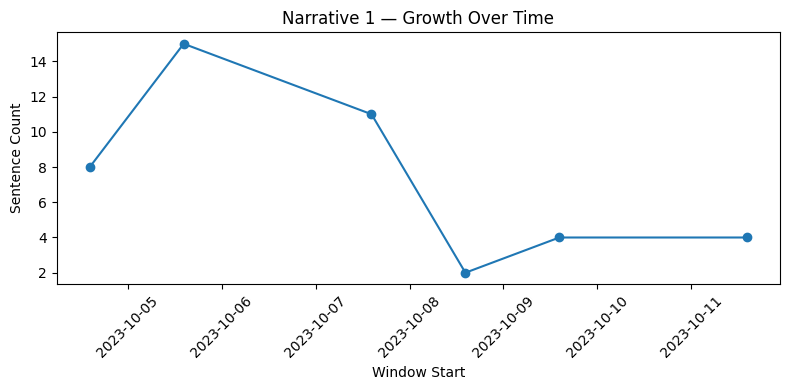

In [ ]:
# =========================
# PEA-1 — Sanity Plot
# =========================

import matplotlib.pyplot as plt

sample_nid = narrative_growth_df["narrative_id"].iloc[0]

sample_data = narrative_growth_df[
    narrative_growth_df["narrative_id"] == sample_nid
]

plt.figure(figsize=(8, 4))
plt.plot(
    sample_data["window_start"],
    sample_data["sentence_count"],
    marker="o"
)
plt.title(f"Narrative {sample_nid} — Growth Over Time")
plt.xlabel("Window Start")
plt.ylabel("Sentence Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# PEA-1 — Persist Outputs
# =========================

ANALYSIS_BASE["narrative_growth"] = narrative_growth_df
ANALYSIS_BASE["frame_growth"] = frame_growth_df

print("PEA-1 outputs saved into ANALYSIS_BASE")


PEA-1 outputs saved into ANALYSIS_BASE


### POST-ENGINE ANALYSIS — PEA-2: Acceleration & Spike Detection


In [ ]:
# =========================
# PEA-2 — Load Growth Tables
# =========================

narrative_growth_df = ANALYSIS_BASE["narrative_growth"].copy()
frame_growth_df = ANALYSIS_BASE["frame_growth"].copy()

print("Loaded growth tables")
print("Narrative growth rows:", len(narrative_growth_df))
print("Frame growth rows:", len(frame_growth_df))


Loaded growth tables
Narrative growth rows: 271
Frame growth rows: 323


In [ ]:
# =========================
# PEA-2 — Narrative Acceleration
# =========================

narrative_growth_df["delta"] = (
    narrative_growth_df
    .groupby("narrative_id")["sentence_count"]
    .diff()
)

print("Narrative deltas computed")
narrative_growth_df.head(10)


Narrative deltas computed


,narrative_id,window_start,sentence_count,cumulative_sentences,delta
0,1,2023-10-04 14:16:02,8,8,NaN
1,1,2023-10-05 14:16:02,15,23,7.0
2,1,2023-10-07 14:16:02,11,34,-4.0
3,1,2023-10-08 14:16:02,2,36,-9.0
4,1,2023-10-09 14:16:02,4,40,2.0
5,1,2023-10-11 14:16:02,4,44,0.0
6,3,2023-10-04 14:16:02,29,29,NaN
7,3,2023-10-05 14:16:02,447,476,418.0
8,3,2023-10-06 14:16:02,332,808,-115.0
9,3,2023-10-07 14:16:02,297,1105,-35.0


In [ ]:
# =========================
# PEA-2 — Narrative Spike Detection
# =========================

def detect_spikes(df, group_col, delta_col, z_thresh=2.0):
    df = df.copy()
    df["z_score"] = (
        df
        .groupby(group_col)[delta_col]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0)
    )
    df["is_spike"] = df["z_score"] >= z_thresh
    return df

narrative_spikes_df = detect_spikes(
    narrative_growth_df,
    group_col="narrative_id",
    delta_col="delta",
    z_thresh=2.0
)

print("Narrative spike detection complete")
narrative_spikes_df[narrative_spikes_df["is_spike"]].head(10)


Narrative spike detection complete


,narrative_id,window_start,sentence_count,cumulative_sentences,delta,z_score,is_spike
7,3,2023-10-05 14:16:02,447,476,418.0,4.346306,True
31,3,2023-10-29 14:16:02,432,5171,310.0,3.223805,True
117,98,2023-12-30 14:16:02,109,209,90.0,2.321715,True
161,108,2024-02-17 14:16:02,133,1559,126.0,2.594315,True
171,108,2024-02-27 14:16:02,198,2376,104.0,2.146632,True
181,108,2024-03-08 14:16:02,147,3146,127.0,2.614665,True
202,108,2024-03-30 14:16:02,130,4728,108.0,2.228029,True
245,148,2024-03-11 14:16:02,10,65,9.0,2.212557,True


In [ ]:
# =========================
# PEA-2 — Frame Acceleration & Spikes
# =========================

frame_growth_df["delta"] = (
    frame_growth_df
    .groupby(["narrative_id", "global_frame_id"])["sentence_count"]
    .diff()
)

frame_spikes_df = detect_spikes(
    frame_growth_df,
    group_col=["narrative_id", "global_frame_id"],
    delta_col="delta",
    z_thresh=2.0
)

print("Frame spike detection complete")
frame_spikes_df[frame_spikes_df["is_spike"]].head(10)


Frame spike detection complete


,narrative_id,global_frame_id,window_start,sentence_count,cumulative_sentences,delta,z_score,is_spike
13,3,3,2023-10-05 14:16:02,447,476,418.0,4.349325,True
37,3,3,2023-10-29 14:16:02,432,5168,310.0,3.226045,True
135,98,10,2023-12-30 14:16:02,109,209,90.0,2.310960,True
183,108,13,2024-02-17 14:16:02,133,1555,126.0,2.601515,True
193,108,13,2024-02-27 14:16:02,198,2371,104.0,2.152589,True
203,108,13,2024-03-08 14:16:02,146,3137,126.0,2.601515,True
224,108,13,2024-03-30 14:16:02,130,4719,108.0,2.234212,True
271,148,21,2024-03-11 14:16:02,8,25,7.0,2.075582,True


In [ ]:
# =========================
# PEA-2 — Persist Outputs
# =========================

ANALYSIS_BASE["narrative_spikes"] = narrative_spikes_df
ANALYSIS_BASE["frame_spikes"] = frame_spikes_df

print("PEA-2 outputs saved into ANALYSIS_BASE")


PEA-2 outputs saved into ANALYSIS_BASE


### POST-ENGINE ANALYSIS — PEA-3: Evidence Backtracking


In [ ]:
# =========================
# PEA-3 — Load Inputs
# =========================

evidence_df = ANALYSIS_BASE["evidence"].copy()
frame_spikes_df = ANALYSIS_BASE["frame_spikes"].copy()

print("Loaded inputs:")
print("Evidence rows:", len(evidence_df))
print("Frame spike rows:", frame_spikes_df["is_spike"].sum())


Loaded inputs:
Evidence rows: 17402
Frame spike rows: 8


In [ ]:
# =========================
# PEA-3 — Frame Centroids
# =========================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Safety check
assert "embedding" in evidence_df.columns, "Evidence embeddings missing"

FRAME_CENTROIDS = {}

grouped = evidence_df.groupby(["narrative_id", "global_frame_id"])

for (nid, fid), group in grouped:
    emb = np.vstack(group["embedding"].values)
    centroid = emb.mean(axis=0)
    FRAME_CENTROIDS[(nid, fid)] = centroid

print("Computed centroids for", len(FRAME_CENTROIDS), "frames")


Computed centroids for 30 frames


In [ ]:
# =========================
# PEA-3 — Backtracking Window Logic
# =========================

# Sort for safety
frame_spikes_df = frame_spikes_df.sort_values("window_start")

# Only actual spikes
frame_spikes_only = frame_spikes_df[frame_spikes_df["is_spike"]]

print("Spike windows to backtrack:", len(frame_spikes_only))


Spike windows to backtrack: 8


In [ ]:
# =========================
# PEA-3 — Evidence Ranking
# =========================

BACKTRACKED_EVIDENCE = []

for _, spike in frame_spikes_only.iterrows():

    nid = spike["narrative_id"]
    fid = spike["global_frame_id"]
    spike_time = spike["window_start"]

    # Define backtracking window (previous + current)
    candidate_evidence = evidence_df[
        (evidence_df["narrative_id"] == nid) &
        (evidence_df["global_frame_id"] == fid) &
        (evidence_df["window_start"] <= spike_time)
    ].copy()

    if candidate_evidence.empty:
        continue

    # Temporal primacy score (earlier = higher score)
    candidate_evidence["time_score"] = (
        (spike_time - candidate_evidence["timestamp"])
        .dt.total_seconds()
        .clip(lower=0)
    )

    # Semantic centrality score
    centroid = FRAME_CENTROIDS.get((nid, fid))
    if centroid is not None:
        sims = cosine_similarity(
            np.vstack(candidate_evidence["embedding"].values),
            centroid.reshape(1, -1)
        ).flatten()
        candidate_evidence["semantic_score"] = sims
    else:
        candidate_evidence["semantic_score"] = 0.0

    # Combined score (simple, defensible)
    candidate_evidence["trigger_score"] = (
        0.6 * candidate_evidence["semantic_score"] +
        0.4 * (1 / (1 + candidate_evidence["time_score"]))
    )

    # Attach spike metadata
    candidate_evidence["spike_window"] = spike_time
    candidate_evidence["spike_delta"] = spike["delta"]

    BACKTRACKED_EVIDENCE.append(candidate_evidence)

print("Backtracking complete")


Backtracking complete


In [ ]:
# =========================
# PEA-3 — Final Evidence Table
# =========================

if BACKTRACKED_EVIDENCE:
    spike_evidence_df = (
        pd.concat(BACKTRACKED_EVIDENCE, ignore_index=True)
        .sort_values("trigger_score", ascending=False)
    )
else:
    spike_evidence_df = pd.DataFrame()

ANALYSIS_BASE["spike_evidence"] = spike_evidence_df

print("Spike evidence rows:", len(spike_evidence_df))
spike_evidence_df.head(10)


Spike evidence rows: 17660


,post_id,source,sentence,timestamp,embedding,embedding_reduced,cluster,window_start,narrative_id,stance,frame_id,global_frame_id,time_score,semantic_score,trigger_score,spike_window,spike_delta
12940,1beahf9,comment,"Netanyahu is bad for absolutely everyone involved, israelis included.",2024-03-14 10:27:41,"[0.13199738, 0.032174714, 0.094130285, -0.031885527, -0.012773341, 0.01919334, -0.018289158, -0.018254673, -0.08121621, 0.00202379, 0.039898258, -0.0023035964, 0.034984678, 0.078163505, -0.01806377, 0.014367783, -0.024563942, -0.05647385, -0.06216321, 0.004493875, -0.070984006, 0.023921434, 0.061966, -0.07204539, 0.025359526, -0.041339945, 0.027849847, 0.005210778, 0.012486537, -0.000331209, -0.046637286, -0.017078552, -0.016280076, 0.014506695, 0.048809253, 0.023479985, -0.00031885208, 0.14227462, 0.034693837, -0.0257354, 0.06385125, 0.051847145, -0.008561787, -0.029207297, 0.019374903, 0.056529656, 0.025633032, -0.06805351, -0.022415753, -0.0076165823, -0.024388539, 0.013267117, 0.108984, 0.0122129945, 0.07178074, -0.0075518484, -0.027889643, 0.02270456, -0.015293135, -0.011334429, 0.07216041, 0.010656668, -0.045179196, -0.072171934, 0.07255836, 0.026673866, 0.007535362, 0.06371275, -0.08672751, 0.005569044, 0.014219533, 0.030585287, -0.012051724, 0.003293212, -0.113136284, -0.097634405, 0.043279145, 0.04886435, 0.012765834, 0.03587759, 0.06720694, -0.015420108, 0.050389163, -0.07984538, 0.1705555, 0.007267717, -0.008029485, -0.0769309, 0.016056927, 0.06880253, -0.038102113, -0.012410531, 0.15698406, -0.024803676, 0.07252396, -0.0019626033, 0.019131184, -0.00038022385, -0.09996846, 0.07280373, ...]","[10.003504, 0.62697494, 5.8241277, 5.076632, 4.132719, 5.1906505, 5.9725537, 4.792832, 2.9841893, 5.2836404, 4.4165998, 5.355528, 4.97221, 5.205645, 5.3250794, 3.554769, 2.6756985, 5.455626, 4.927552, 3.2041607, 4.996553, 4.887478, 4.8394337, 4.5839, 5.0900517, 4.721134, 2.264083, 4.8756895, 3.946631, 6.54281, 7.2550483, 2.0756562, 5.5638833, 5.2545347, 3.1310139, 4.879317, 4.4357033, 5.256869, 5.447509, 5.5248203, 5.262874, 2.5916228, 5.8299365, 5.5814466, 1.4222972, 3.9345527, 5.0037436, 4.3320217, 4.8822803, 4.8553495]",0,2024-03-11 14:16:02,148,-0.5423,0,21,0.0,0.843179,0.905908,2024-03-11 14:16:02,7.0
7304,1atwcpi,comment,There is something deeply collectively pathological about the behavior of the Zionists against the Palestinians.,2024-02-18 19:58:29,"[0.012493592, 0.016342498, -0.0047584674, 0.007812614, -0.0019930117, -0.03841198, -0.009133678, -0.07606807, -0.011936962, -0.00019285973, -0.011741939, 0.03194579, 0.032889105, 0.04160039, 0.04005521, -0.03180009, -0.10198194, -0.01485205, -0.07204139, 0.0274291, -0.022356091, 0.019510468, 0.062145818, 0.006881772, -0.07461722, 0.05325528, 0.0278874, -0.06414081, -0.010318228, -0.005471937, -0.031796332, 0.019175021, -0.0040518935, 0.004700835, 0.014997328, 0.10649215, 0.06837159, 0.09609864, -0.0320099, -0.10160861, 0.052721635, 0.013169336, 0.04150013, -0.005304036, -0.03562388, 0.049488537, -0.029635059, -0.042497236, 0.0017618372, -0.00071114197, -0.065049976, -0.027547834, 0.08186473, -0.054029964, -0.008881967, -0.12047985, -0.019669516, 0.019770226, 0.063359976, -0.041163806, 0.1037294, 0.018007096, -0.020474529, -0.01620683, 0.1146884, -0.063524, 0.06550521, 0.006039845, -0.07848334, -0.01772126, 0.029019926, 0.03322406, -0.029206926, 0.054931473, -0.02753332, -0.04071967, 0.0036709832, 0.003894961, -0.027248941, -0.02445956, 0.059650987, -0.036074236, 0.06582992, -0.056904644, 0.11254616, 0.0086287325, 0.01275564, -0.052630167, 0.0880707, 0.0018120026, -0.049398616, -0.082522385, 0.11652237, -0.08954344, 0.07566867, -0.046075173, -0.032202512, -0.03252616, 0.05856404, 0.05880176, ...]","[9.937006, 3.6396625, 5.9386606, 5.9045444, 4.485356, 4.952884, 5.4878182, 5.504499, 5.474718, 5.1134067, 5.197808, 5.877201, 5.5397606, 4.953594, 5.164639, 3.7474408, 2.1163173, 5.4103465, 5.0328436, 2.885412, 4.889513, 4.5050387, 5.303199, 3.5285428, 5.3786774, 4.8526425, 2.05

In [ ]:
ANALYSIS_BASE["spike_evidence"]


,post_id,source,sentence,timestamp,embedding,embedding_reduced,cluster,window_start,narrative_id,stance,frame_id,global_frame_id,time_score,semantic_score,trigger_score,spike_window,spike_delta
12940,1beahf9,comment,"Netanyahu is bad for absolutely everyone involved, israelis included.",2024-03-14 10:27:41,"[0.13199738, 0.032174714, 0.094130285, -0.031885527, -0.012773341, 0.01919334, -0.018289158, -0.018254673, -0.08121621, 0.00202379, 0.039898258, -0.0023035964, 0.034984678, 0.078163505, -0.01806377, 0.014367783, -0.024563942, -0.05647385, -0.06216321, 0.004493875, -0.070984006, 0.023921434, 0.061966, -0.07204539, 0.025359526, -0.041339945, 0.027849847, 0.005210778, 0.012486537, -0.000331209, -0.046637286, -0.017078552, -0.016280076, 0.014506695, 0.048809253, 0.023479985, -0.00031885208, 0.14227462, 0.034693837, -0.0257354, 0.06385125, 0.051847145, -0.008561787, -0.029207297, 0.019374903, 0.056529656, 0.025633032, -0.06805351, -0.022415753, -0.0076165823, -0.024388539, 0.013267117, 0.108984, 0.0122129945, 0.07178074, -0.0075518484, -0.027889643, 0.02270456, -0.015293135, -0.011334429, 0.07216041, 0.010656668, -0.045179196, -0.072171934, 0.07255836, 0.026673866, 0.007535362, 0.06371275, -0.08672751, 0.005569044, 0.014219533, 0.030585287, -0.012051724, 0.003293212, -0.113136284, -0.097634405, 0.043279145, 0.04886435, 0.012765834, 0.03587759, 0.06720694, -0.015420108, 0.050389163, -0.07984538, 0.1705555, 0.007267717, -0.008029485, -0.0769309, 0.016056927, 0.06880253, -0.038102113, -0.012410531, 0.15698406, -0.024803676, 0.07252396, -0.0019626033, 0.019131184, -0.00038022385, -0.09996846, 0.07280373, ...]","[10.003504, 0.62697494, 5.8241277, 5.076632, 4.132719, 5.1906505, 5.9725537, 4.792832, 2.9841893, 5.2836404, 4.4165998, 5.355528, 4.97221, 5.205645, 5.3250794, 3.554769, 2.6756985, 5.455626, 4.927552, 3.2041607, 4.996553, 4.887478, 4.8394337, 4.5839, 5.0900517, 4.721134, 2.264083, 4.8756895, 3.946631, 6.54281, 7.2550483, 2.0756562, 5.5638833, 5.2545347, 3.1310139, 4.879317, 4.4357033, 5.256869, 5.447509, 5.5248203, 5.262874, 2.5916228, 5.8299365, 5.5814466, 1.4222972, 3.9345527, 5.0037436, 4.3320217, 4.8822803, 4.8553495]",0,2024-03-11 14:16:02,148,-0.5423,0,21,0.0,0.843179,0.905908,2024-03-11 14:16:02,7.0
7304,1atwcpi,comment,There is something deeply collectively pathological about the behavior of the Zionists against the Palestinians.,2024-02-18 19:58:29,"[0.012493592, 0.016342498, -0.0047584674, 0.007812614, -0.0019930117, -0.03841198, -0.009133678, -0.07606807, -0.011936962, -0.00019285973, -0.011741939, 0.03194579, 0.032889105, 0.04160039, 0.04005521, -0.03180009, -0.10198194, -0.01485205, -0.07204139, 0.0274291, -0.022356091, 0.019510468, 0.062145818, 0.006881772, -0.07461722, 0.05325528, 0.0278874, -0.06414081, -0.010318228, -0.005471937, -0.031796332, 0.019175021, -0.0040518935, 0.004700835, 0.014997328, 0.10649215, 0.06837159, 0.09609864, -0.0320099, -0.10160861, 0.052721635, 0.013169336, 0.04150013, -0.005304036, -0.03562388, 0.049488537, -0.029635059, -0.042497236, 0.0017618372, -0.00071114197, -0.065049976, -0.027547834, 0.08186473, -0.054029964, -0.008881967, -0.12047985, -0.019669516, 0.019770226, 0.063359976, -0.041163806, 0.1037294, 0.018007096, -0.020474529, -0.01620683, 0.1146884, -0.063524, 0.06550521, 0.006039845, -0.07848334, -0.01772126, 0.029019926, 0.03322406, -0.029206926, 0.054931473, -0.02753332, -0.04071967, 0.0036709832, 0.003894961, -0.027248941, -0.02445956, 0.059650987, -0.036074236, 0.06582992, -0.056904644, 0.11254616, 0.0086287325, 0.01275564, -0.052630167, 0.0880707, 0.0018120026, -0.049398616, -0.082522385, 0.11652237, -0.08954344, 0.07566867, -0.046075173, -0.032202512, -0.03252616, 0.05856404, 0.05880176, ...]","[9.937006, 3.6396625, 5.9386606, 5.9045444, 4.485356, 4.952884, 5.4878182, 5.504499, 5.474718, 5.1134067, 5.197808, 5.877201, 5.5397606, 4.953594, 5.164639, 3.7474408, 2.1163173, 5.4103465, 5.0328436, 2.885412, 4.889513, 4.5050387, 5.303199, 3.5285428, 5.3786774, 4.8526425, 2.05

### POST-ENGINE ANALYSIS — PEA-3-OPT: Law-Enforcement Hardening


In [ ]:
# =========================
# PEA-3-OPT — Load Inputs
# =========================

spike_evidence_full_df = ANALYSIS_BASE["spike_evidence"].copy()
frame_spikes_df = ANALYSIS_BASE["frame_spikes"].copy()

assert "is_spike" in frame_spikes_df.columns
assert not spike_evidence_full_df.empty

print("Loaded spike evidence:", len(spike_evidence_full_df))
print("Spike windows:", frame_spikes_df["is_spike"].sum())


Loaded spike evidence: 17660
Spike windows: 8


In [ ]:
# =========================
# PEA-3-OPT — Spike ID Assignment
# =========================

spike_events_df = (
    frame_spikes_df[frame_spikes_df["is_spike"]]
    .reset_index(drop=True)
    .copy()
)

spike_events_df["spike_id"] = (
    "SPIKE_" + spike_events_df.index.astype(str)
)

print("Created", len(spike_events_df), "spike IDs")
spike_events_df.head()


Created 8 spike IDs


,narrative_id,global_frame_id,window_start,sentence_count,cumulative_sentences,delta,z_score,is_spike,spike_id
0,3,3,2023-10-05 14:16:02,447,476,418.0,4.349325,True,SPIKE_0
1,3,3,2023-10-29 14:16:02,432,5168,310.0,3.226045,True,SPIKE_1
2,98,10,2023-12-30 14:16:02,109,209,90.0,2.310960,True,SPIKE_2
3,108,13,2024-02-17 14:16:02,133,1555,126.0,2.601515,True,SPIKE_3
4,108,13,2024-02-27 14:16:02,198,2371,104.0,2.152589,True,SPIKE_4


In [ ]:
# =========================
# PEA-3-OPT — Hard Window Bounding
# =========================

WINDOW_SIZE = pd.Timedelta(days=3)  # matches your 72h window

bounded_rows = []

for _, spike in spike_events_df.iterrows():

    nid = spike["narrative_id"]
    fid = spike["global_frame_id"]
    spike_time = spike["window_start"]

    window_start = spike_time - WINDOW_SIZE

    subset = spike_evidence_full_df[
        (spike_evidence_full_df["narrative_id"] == nid) &
        (spike_evidence_full_df["global_frame_id"] == fid) &
        (spike_evidence_full_df["timestamp"] >= window_start) &
        (spike_evidence_full_df["timestamp"] <= spike_time)
    ].copy()

    subset["spike_id"] = spike["spike_id"]
    bounded_rows.append(subset)

bounded_evidence_df = pd.concat(bounded_rows, ignore_index=True)

print("Bounded evidence rows:", len(bounded_evidence_df))


Bounded evidence rows: 2000


In [ ]:
# =========================
# PEA-3-OPT — Score Transparency
# =========================

bounded_evidence_df["semantic_component"] = bounded_evidence_df["semantic_score"]
bounded_evidence_df["temporal_component"] = (
    1 / (1 + bounded_evidence_df["time_score"])
)

bounded_evidence_df["trigger_score"] = (
    0.6 * bounded_evidence_df["semantic_component"] +
    0.4 * bounded_evidence_df["temporal_component"]
)

print("Score components added")


Score components added


In [ ]:
# =========================
# PEA-3-OPT — Top-K Per Spike
# =========================

TOP_K = 15  # defensible range: 10–20

spike_evidence_topk_df = (
    bounded_evidence_df
    .sort_values("trigger_score", ascending=False)
    .groupby("spike_id")
    .head(TOP_K)
    .reset_index(drop=True)
)

print("Top-K evidence rows:", len(spike_evidence_topk_df))
spike_evidence_topk_df.head(10)


Top-K evidence rows: 90


,post_id,source,sentence,timestamp,embedding,embedding_reduced,cluster,window_start,narrative_id,stance,frame_id,global_frame_id,time_score,semantic_score,trigger_score,spike_window,spike_delta,spike_id,semantic_component,temporal_component
0,1bqp9y2,comment,I can't say i hold the Palestinians in much regard but these Israelis have come across as utter bastards.,2024-03-29 14:33:42,"[0.010112997, 0.064201705, 0.010839752, -0.07437185, -0.022570776, -0.07255555, 0.027453342, -0.08672323, 0.01972637, 0.022560384, -0.012802202, -0.028240368, 0.004868845, -0.03233671, 0.02113183, -0.021417925, -0.08576489, -0.09488335, -0.010505457, 0.042473357, 0.0047004656, 0.0070982226, 0.05489046, 0.0071470407, -0.024337796, 0.03633162, 0.031714063, -0.034023494, 0.032666642, -0.023558564, -0.026676819, 0.022582466, -0.04584187, 0.00032508248, -0.010438125, 0.10955885, -0.003911869, 0.10065501, -0.014084303, -0.104914114, 0.091767594, 0.045136724, 0.0793028, 0.0061056004, 0.051869277, 0.046279505, 0.0069711916, -0.015798545, 0.0018859245, 0.019571044, -0.05185635, -0.006399807, 0.09194954, -0.0868526, -0.060480326, -0.10477313, -0.0056733508, -0.0054489435, 0.051939897, -0.05622983, 0.030585473, 0.03685765, -0.022116588, -0.055873193, -0.000333892, -0.0011017983, -0.018721623, 0.036191963, -0.107996866, 0.0397916, -0.015152816, 0.059655204, 0.017348079, 0.09328839, -0.051721327, -0.07505062, 0.007171485, -0.0068154777, -0.0050627543, 0.027344385, 0.007520222, -0.014816051, -0.0031824072, -0.06145111, 0.06873331, -0.006019137, 0.007733744, -0.053734805, 0.07194987, -0.018479528, -0.015287001, -0.053315174, 0.16899472, -0.029428646, 0.10272323, -0.069930516, -0.0049540442, 0.06279448, -0.03216792, 0.057064496, ...]","[9.943875, 3.6449559, 5.938155, 5.8886456, 4.5174475, 4.9840746, 5.6648307, 5.362485, 5.561076, 5.095852, 5.3056374, 6.048823, 5.5956903, 4.93699, 5.1266546, 3.7177155, 2.057516, 5.4151497, 5.0205526, 2.844193, 4.908219, 4.4808016, 5.3634286, 3.3920245, 5.4118705, 4.87368, 2.045779, 4.449457, 2.8906853, 7.2666726, 7.532968, 1.8628252, 4.9846225, 5.2325435, 3.7009664, 4.432044, 4.0827293, 4.6543245, 4.65903, 5.210511, 5.763524, 2.9024613, 5.7304115, 5.5457, 1.8790538, 4.0946794, 4.7448277, 4.176424, 4.783647, 4.566918]",1,2024-03-28 14:16:02,108,-0.7579,1,13,85340.0,0.781099,0.468664,2024-03-30 14:16:02,108.0,SPIKE_6,0.781099,1.171770e-05
1,1ayt7ob,comment,"Funny, I’ve never heard a “pro-Palestinian” talk about that.",2024-02-24 14:54:51,"[0.078040995, 0.03442421, -0.03908679, -0.037676483, 0.021603458, -0.047809474, 0.05123557, -0.08649086, -0.0076045394, 0.047033526, 0.021041874, 0.054634906, -0.01653384, 0.0022225413, 0.06816661, -0.029849295, -0.0350169, -0.06527693, -0.0026347402, -0.023296695, -0.021469662, -0.046814058, 0.10038352, 0.026970806, 0.019980097, -0.03058125, 0.032813918, -0.004637141, -0.02655336, 0.024099045, -0.016391868, 0.012551762, -0.053084143, -0.01867836, 0.07685563, 0.12612385, -0.05355295, 0.107652366, 0.0170564, -0.017917966, 0.12568435, -0.03437898, 0.025907665, -0.053207543, 0.039603423, 0.057064123, -0.020365782, 0.031054474, -0.025454585, -0.0028106896, 0.022528721, -0.046135273, 0.0861119, -0.059635017, -0.043624867, -0.042255804, -0.016443146, -0.017695937, 0.043052, -0.038600456, 0.0061121583, 0.020095892, -0.08289298, -0.031935617, 0.032145515, -0.020479979, 0.037382074, 0.04103235, -0.12503342, -0.0007797724, 0.008513105, 0.09130722, -0.005950833, 0.14822848, -0.026738461, -0.111851364, 0.0204829, 0.009596468, -0.026344676, 0.027721677, 0.05429943, 0.014935388, 0.0004213065, -0.046522383, 0.019205123, -0.019546775, 0.034037195, -0.02658726, 0.016019512, -0.08681905, -0.041776434, -0.081932075, 0.10646123, -0.03959796, 0.041324217, -0.07753857, -0.041232977, 0.026303891, -0.012149211, -0.0038102008, ...]","[9.939636, 3.5327632, 5.9280963, 5.9774804, 4.520536, 5.086129, 5.9089174, 5.4816875, 5.367968, 5.1451283, 5.068245, 5.697585, 5.656258, 5.0450726, 5.2862096, 3.9537668, 2.3313978, 5.433385, 5.

In [ ]:
# =========================
# PEA-3-OPT — Persist Outputs
# =========================

ANALYSIS_BASE["spike_events"] = spike_events_df
ANALYSIS_BASE["spike_evidence_bounded"] = bounded_evidence_df
ANALYSIS_BASE["spike_evidence_topk"] = spike_evidence_topk_df

print("""
PEA-3 OPTIMIZATION COMPLETE
--------------------------------
• spike_events           → event handles
• spike_evidence_bounded → audit-safe
• spike_evidence_topk    → operational (LE/dashboard)
""")



PEA-3 OPTIMIZATION COMPLETE
--------------------------------
• spike_events           → event handles
• spike_evidence_bounded → audit-safe
• spike_evidence_topk    → operational (LE/dashboard)



In [ ]:
len(spike_evidence_full_df), len(bounded_evidence_df), len(spike_evidence_topk_df)
# VERIFICATION CELL

(17660, 2000, 90)

In [ ]:

# VERIFICATION CELL
sample_spike = spike_evidence_topk_df["spike_id"].iloc[0]

spike_evidence_topk_df[
    spike_evidence_topk_df["spike_id"] == sample_spike
][[
    "narrative_id",
    "global_frame_id",
    "sentence",
    "timestamp",
    "post_id",
    "semantic_component",
    "temporal_component",
    "trigger_score"
]]


,narrative_id,global_frame_id,sentence,timestamp,post_id,semantic_component,temporal_component,trigger_score
0,108,13,I can't say i hold the Palestinians in much regard but these Israelis have come across as utter bastards.,2024-03-29 14:33:42,1bqp9y2,0.781099,0.000012,0.468664
27,108,13,That will require a serious change of leadership or public opinion turning so completely against Israel that it would be political suicide to continue enabling them.,2024-03-30 04:20:52,1br806c,0.750359,0.000028,0.450227
47,108,13,And this is why we separate innocent Jewish people from Israel's government.,2024-03-28 16:11:58,1bpxp8a,0.741844,0.000006,0.445109
54,108,13,“Failed to empathize with their colleagues in Gaza and continue to abdicate their responsibility to denounce Israel’s crimes”\n\nWhat?,2024-03-28 14:33:14,1bpuqyr,0.734215,0.000006,0.440531
59,108,13,“This isn’t Gaza” so they acknowledge how bad it is in Gaza?,2024-03-27 15:38:05,1bp449r,0.730977,0.000004,0.438588
62,108,13,Everyone acting like this is a handout to Israel or something.,2024-03-30 07:04:07,1br806c,0.723721,0.000039,0.434248
68,108,13,It’s not Gaza but it sure af is still in Palestine,2024-03-27 15:37:16,1bp449r,0.713564,0.000004,0.428140
69,108,13,"I don't know how else to slice it, what is happening in Gaza is absolutely horrific on an unimaginable scale, from mass hunger, to bombing crap outta dense civilian pockets, to bulldozing homes and olive trees in the West Bank.",2024-03-27 17:43:14,1bp7740,0.712906,0.000004,0.427745
70,108,13,This is America's campaign just as much as it is Israel's.,2024-03-30 04:32:14,1br806c,0.712426,0.000029,0.427467
71,108,13,Dam savages is what the Israeli military is.,2024-03-28 12:01:25,1bptea6,0.710618,0.000006,0.426373


In [ ]:
# VERIFICATION CELL
spike_evidence_topk_df.groupby("spike_id").size()


,0
spike_id,
SPIKE_1,15
SPIKE_2,15
SPIKE_3,15
SPIKE_4,15
SPIKE_5,15
SPIKE_6,15


### POST-ENGINE ANALYSIS — PEA-4: Narrative & Frame Mutation


In [ ]:
# =========================
# PEA-4 — Load Inputs
# =========================

evidence_df = ANALYSIS_BASE["evidence"].copy()

required_cols = {
    "narrative_id",
    "global_frame_id",
    "window_start",
    "embedding",
    "sentence"
}

missing = required_cols - set(evidence_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Evidence loaded for mutation analysis:", len(evidence_df))


Evidence loaded for mutation analysis: 17402


In [ ]:
# =========================
# PEA-4 — Windowed Centroids
# =========================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

windowed_centroids = []

grouped = evidence_df.groupby(
    ["narrative_id", "global_frame_id", "window_start"]
)

for (nid, fid, wstart), group in grouped:
    emb = np.vstack(group["embedding"].values)
    centroid = emb.mean(axis=0)
    windowed_centroids.append({
        "narrative_id": nid,
        "global_frame_id": fid,
        "window_start": wstart,
        "centroid": centroid,
        "sentence_count": len(group)
    })

windowed_centroids_df = pd.DataFrame(windowed_centroids)

print("Windowed centroids computed:", len(windowed_centroids_df))
windowed_centroids_df.head()


Windowed centroids computed: 323


,narrative_id,global_frame_id,window_start,centroid,sentence_count
0,1,0,2023-10-04 14:16:02,"[0.027089281, 0.07774144, 0.02476693, -0.029349275, -0.023465319, -0.0024466836, 0.0015498727, -0.09341738, -0.035623617, 0.024551664, -0.016000608, 0.039983895, 0.020940939, 0.050578896, 0.007903932, -0.041780785, -0.043365512, -0.06712249, -0.039257456, 0.0066552944, 0.011933494, 0.039372485, 0.09794894, 0.0022399903, -0.0006835358, 0.017400363, 0.009199876, -0.0060448013, -0.0066653937, -0.008669809, 0.014229957, -0.0075126863, -0.042066127, 0.024329826, -0.008240489, 0.0586885, 0.023501309, 0.027849736, 0.052807778, -0.06149609, 0.059850253, -0.014344893, 0.006709256, -0.019389909, 0.015194748, 0.044235654, 0.0059973965, -0.022961581, -0.010782662, 0.020468038, 0.008925663, -0.0062216185, 0.049194563, -0.054090355, 0.020721225, -0.028611949, -0.004648408, -0.047059186, 0.029785812, -0.02615236, -0.020938694, -0.013742882, -0.018600933, -0.04012078, -0.0059503047, -0.02742586, 0.074696705, 0.022110242, -0.083927296, 0.00034740544, 0.004540935, 0.03429815, -0.00024705706, 0.013090894, -0.027014958, -0.049532518, 0.035723954, -0.0059145596, -0.0006587277, -0.01594684, 0.020302206, -0.060882434, 0.016370222, -0.010692546, 0.05218272, 0.031008564, 0.019227771, -0.041648015, 0.06999333, 0.0030619383, -0.024830397, -0.035490654, 0.11546633, -0.0022694636, 0.04109067, 0.027158296, 0.0060599414, 0.0052129934, -0.061083663, 0.029806018, ...]",8
1,1,0,2023-10-05 14:16:02,"[0.0293234, 0.032953516, 0.06880945, -0.03415946, 0.011533495, 0.016699145, 0.016862478, -0.051046174, -0.03218222, 0.004005335, 0.007729958, 0.021866838, 0.018379603, 0.04536585, 0.04015742, 0.048626535, -0.058479413, -0.049822845, -0.031838175, 0.013484686, -0.013894143, 0.04775989, 0.055219445, -0.024721352, 0.029495357, 0.012698456, 0.024587099, 0.0142274145, -0.011069362, -2.5511934e-05, 0.021421641, 0.0013229436, -0.06843029, -0.017955009, 0.042645182, 0.034584757, 0.009006452, 0.07688535, 0.03512086, -0.04120148, 0.03761236, -0.052977268, 0.007150499, -0.01129114, 0.024096968, 0.062445197, 0.001168882, -0.030232705, 0.037068233, -0.035835806, -0.012175889, -0.029381942, 0.0823047, -0.02328794, 0.028403044, -0.034008563, 0.003974673, 0.004454022, 0.017967207, -0.02804372, -0.006746952, 0.0076735616, -0.03437281, -0.042928047, 0.039544918, 0.013905278, 0.040250197, 0.028202979, -0.0795796, 0.023774836, 0.05441892, 0.0455255, 0.010504476, -0.01295892, -0.051090643, -0.06645456, 0.008821047, 0.048480235, 0.029901229, 0.018495915, 0.013099184, -0.008083666, 0.02511277, -0.029246042, 0.08408829, -0.02006755, -0.024211876, -0.031147953, 0.036996204, 0.029508425, -0.05349763, -0.037553817, 0.09052122, 0.004473014, 0.034161344, -0.0057571977, 0.009362035, 0.0100515485, -0.06198038, 0.055927195, ...]",13
2,1,0,2023-10-07 14:16:02,"[0.012226678, 0.05460929, 0.076637425, 0.016583996, -0.010749183, -0.015954724, 0.017960886, -0.018003762, -0.029329674, -0.006646398, 0.016109278, 0.04182179, 0.030071478, 0.05718143, 0.020873046, 0.026739191, -0.061716914, -0.035525043, -0.06735276, 0.00086084864, -0.001871285, 0.050467968, 0.03782543, -0.053339507, 0.03255934, -0.012152986, 0.013003429, 0.014559855, -0.007538297, -0.016022187, 0.0060715913, -0.010130377, -0.045970846, -0.0033615406, 0.052450385, 0.05283767, 0.023820251, 0.06205549, 0.055428453, -0.039883584, 0.06305211, -0.040722918, 0.012874766, -0.0057919803, 0.004572496, 0.04959366, 0.04091835, -0.03958758, 0.02847721, -0.01504201, -0.043226648, -0.025667088, 0.06770702, -0.077218615, 0.023979573, -0.057074867, 0.010403146, 0.0015452073, 0.014031441, -0.023151666, 0.0126920035, 0.0041918755, -0.010593415, -0.02394096, 0.05784688, 0.005518093, 0.037402127, -0.0068666893, -0.051978942, 0.03544592, 0.030519651, 0.025690967, -0.021785809, -0.013273141, -0.08458172, -0.101428114, 0.01760358, 0.04376471, 0.0142479595, 0.007968119, 0.018347615, -0.019654062, 0.03730822, -0.0061038057, 0.08568172, -0.004797136, -0.0016462824, -0.034931

In [ ]:
# =========================
# PEA-4 — Centroid Drift
# =========================

drift_rows = []

for (nid, fid), group in windowed_centroids_df.groupby(
    ["narrative_id", "global_frame_id"]
):
    group = group.sort_values("window_start").reset_index(drop=True)

    for i in range(1, len(group)):
        prev = group.loc[i - 1]
        curr = group.loc[i]

        drift = 1 - cosine_similarity(
            prev["centroid"].reshape(1, -1),
            curr["centroid"].reshape(1, -1)
        )[0][0]

        drift_rows.append({
            "narrative_id": nid,
            "global_frame_id": fid,
            "window_start": curr["window_start"],
            "centroid_drift": drift,
            "sentence_count": curr["sentence_count"]
        })

frame_drift_df = pd.DataFrame(drift_rows)

print("Frame drift computed:", len(frame_drift_df))
frame_drift_df.head()


Frame drift computed: 293


,narrative_id,global_frame_id,window_start,centroid_drift,sentence_count
0,1,0,2023-10-05 14:16:02,0.326971,13
1,1,0,2023-10-07 14:16:02,0.128856,7
2,1,0,2023-10-08 14:16:02,0.243984,2
3,1,0,2023-10-09 14:16:02,0.291991,4
4,1,0,2023-10-11 14:16:02,0.206714,3


In [ ]:
# =========================
# PEA-4 — Lexical Turnover
# =========================

from sklearn.feature_extraction.text import TfidfVectorizer

LEXICAL_CHANGES = []

for (nid, fid), group in evidence_df.groupby(
    ["narrative_id", "global_frame_id"]
):

    windows = sorted(group["window_start"].unique())

    if len(windows) < 2:
        continue

    for i in range(1, len(windows)):
        w_prev = windows[i - 1]
        w_curr = windows[i]

        prev_text = " ".join(
            group[group["window_start"] == w_prev]["sentence"]
        )
        curr_text = " ".join(
            group[group["window_start"] == w_curr]["sentence"]
        )

        vectorizer = TfidfVectorizer(
            stop_words="english",
            max_features=50
        )

        X = vectorizer.fit_transform([prev_text, curr_text])
        features = vectorizer.get_feature_names_out()

        prev_vec, curr_vec = X.toarray()

        gained = features[(curr_vec - prev_vec) > 0.05].tolist()
        lost = features[(prev_vec - curr_vec) > 0.05].tolist()

        LEXICAL_CHANGES.append({
            "narrative_id": nid,
            "global_frame_id": fid,
            "window_start": w_curr,
            "keywords_gained": gained,
            "keywords_lost": lost
        })

lexical_shift_df = pd.DataFrame(LEXICAL_CHANGES)

print("Lexical shifts computed:", len(lexical_shift_df))
lexical_shift_df.head()


Lexical shifts computed: 293


,narrative_id,global_frame_id,window_start,keywords_gained,keywords_lost
0,1,0,2023-10-05 14:16:02,"[07, 10, 2023, attack, attacks, biden, cnn, com, condemning, gaza, hamas, house, https, joe, live, metered, netanyahu, palestinians, paywall, president, really, remarks, says, situation, statement, support, surprise, terrorist, updates, war, white, world, www]","[going, hard, israel, israeli, israelis, like, response, right, sure]"
1,1,0,2023-10-07 14:16:02,"[10, attack, gazans, general, government, idea, intelligence, iran, israeli, kamel, likely, massive, military, minister, netanyahu, news, power, said]","[07, 2023, attacks, biden, cnn, com, condemning, gaza, hamas, house, https, israel, joe, live, metered, paywall, president, really, remarks, says, situation, statement, surprise, terrorist, updates, war, white, world, www]"
2,1,0,2023-10-08 14:16:02,"[allowed, benjamin, civilians, continued, correct, deliberately, furious, israeli, justification, kill, killed, man]","[10, abbas, attack, bank, biden, cabal, called, coming, corrupt, country, days, egypt, egyptian, focused, gazans, general, government, happen, idea, incompetent, indifference, installing, intelligence, iran, kamel, likely, massive, military, minister, news, operation, personally, said, site, terrible, told, unusual]"
3,1,0,2023-10-09 14:16:02,"[aircraft, biden, carrier, continual, damning, denying, emergency, encroachment, happen, intelligence, israel, land, let, mention, optics, powers, pretty, sending, simply, support, surprised, suspicious, unequivocal, unnecessary, use, warnings, wouldn]","[allowed, benjamin, civilians, continued, correct, deliberately, furious, justification, kill, killed, lived, low, lowest, man, read, rule, situation]"
4,1,0,2023-10-11 14:16:02,"[actually, beg, bruh, calling, cking, comment, contributed, criminal, dealt, donkeys, edit, escaping, food, gantz, gaza, going, hamas, jeopardize, jew, maybe, medicinal, moment, morning, motherf, people, positive, power, president, pressure, reception]","[aircraft, biden, carrier, continual, damning, denying, emergency, encroachment, happen, intelligence, israel, israeli, land, let, mention, optics, palestinian, powers, pretty]"


In [ ]:
# =========================
# PEA-4 — Persist Outputs
# =========================

ANALYSIS_BASE["frame_drift"] = frame_drift_df
ANALYSIS_BASE["lexical_shift"] = lexical_shift_df

print("""
PEA-4 COMPLETE
--------------------------------
• frame_drift     → semantic mutation signal
• lexical_shift   → explainable framing change
""")



PEA-4 COMPLETE
--------------------------------
• frame_drift     → semantic mutation signal
• lexical_shift   → explainable framing change



In [ ]:
# =========================
# PEA-4-OPT — Drift Reliability Gate
# =========================

MIN_SENTENCES = 5  # defensible threshold

frame_drift_df = ANALYSIS_BASE["frame_drift"].copy()

frame_drift_df["is_reliable_drift"] = (
    frame_drift_df["sentence_count"] >= MIN_SENTENCES
)

ANALYSIS_BASE["frame_drift"] = frame_drift_df

print("Reliable drift rows:",
      frame_drift_df["is_reliable_drift"].sum(),
      "out of",
      len(frame_drift_df))


Reliable drift rows: 218 out of 293


In [ ]:
# VERIFIACTION CELL
frame_drift_df["centroid_drift"].describe()


,centroid_drift
count,293.000000
mean,0.151689
std,0.141179
min,0.009359
25%,0.044473
50%,0.086906
75%,0.230691
max,0.626126


In [ ]:
# VERIFICATION CELL
frame_drift_df.sort_values(
    "centroid_drift", ascending=False
).head(10)


,narrative_id,global_frame_id,window_start,centroid_drift,sentence_count
272,181,24,2024-03-30 14:16:02,0.626126,1
282,181,25,2024-04-02 14:16:02,0.603506,1
95,3,4,2023-11-07 14:16:02,0.536186,1
157,108,13,2024-02-03 14:16:02,0.523273,21
255,148,22,2024-02-29 14:16:02,0.513545,1
7,3,2,2023-10-31 14:16:02,0.506868,1
231,108,14,2024-01-22 14:16:02,0.498397,1
242,148,21,2024-02-24 14:16:02,0.489864,1
156,108,13,2024-02-02 14:16:02,0.488933,2
232,108,14,2024-02-20 14:16:02,0.481849,1


In [ ]:
# VERIFICATION CELL
lexical_shift_df.head(5)



,narrative_id,global_frame_id,window_start,keywords_gained,keywords_lost
0,1,0,2023-10-05 14:16:02,"[07, 10, 2023, attack, attacks, biden, cnn, com, condemning, gaza, hamas, house, https, joe, live, metered, netanyahu, palestinians, paywall, president, really, remarks, says, situation, statement, support, surprise, terrorist, updates, war, white, world, www]","[going, hard, israel, israeli, israelis, like, response, right, sure]"
1,1,0,2023-10-07 14:16:02,"[10, attack, gazans, general, government, idea, intelligence, iran, israeli, kamel, likely, massive, military, minister, netanyahu, news, power, said]","[07, 2023, attacks, biden, cnn, com, condemning, gaza, hamas, house, https, israel, joe, live, metered, paywall, president, really, remarks, says, situation, statement, surprise, terrorist, updates, war, white, world, www]"
2,1,0,2023-10-08 14:16:02,"[allowed, benjamin, civilians, continued, correct, deliberately, furious, israeli, justification, kill, killed, man]","[10, abbas, attack, bank, biden, cabal, called, coming, corrupt, country, days, egypt, egyptian, focused, gazans, general, government, happen, idea, incompetent, indifference, installing, intelligence, iran, kamel, likely, massive, military, minister, news, operation, personally, said, site, terrible, told, unusual]"
3,1,0,2023-10-09 14:16:02,"[aircraft, biden, carrier, continual, damning, denying, emergency, encroachment, happen, intelligence, israel, land, let, mention, optics, powers, pretty, sending, simply, support, surprised, suspicious, unequivocal, unnecessary, use, warnings, wouldn]","[allowed, benjamin, civilians, continued, correct, deliberately, furious, justification, kill, killed, lived, low, lowest, man, read, rule, situation]"
4,1,0,2023-10-11 14:16:02,"[actually, beg, bruh, calling, cking, comment, contributed, criminal, dealt, donkeys, edit, escaping, food, gantz, gaza, going, hamas, jeopardize, jew, maybe, medicinal, moment, morning, motherf, people, positive, power, president, pressure, reception]","[aircraft, biden, carrier, continual, damning, denying, emergency, encroachment, happen, intelligence, israel, israeli, land, let, mention, optics, palestinian, powers, pretty]"


CELL 1

In [ ]:
# ==========================================
# FRAME LABELING — THEME EXTRACTION SETUP (FINAL, RELIABLE)
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
import re
import numpy as np

# Conflict-relevant vocabulary to bias labeling
CONFLICT_TERMS = [
    "israel", "palestine", "gaza", "hamas", "idf", "ceasefire", "hostage",
    "genocide", "occupation", "bombing", "strike", "drone", "settlement",
    "netanyahu", "biden", "zionism", "antisemitism", "aid", "refugee",
    "war crimes", "civilians", "children", "hospital", "surveillance",
    "missile", "iran", "hezbollah", "protest", "sanctions"
]

print("Theme extraction setup ready ✅")


Theme extraction setup ready ✅


In [ ]:
# ==========================================
# FRAME SAMPLES — COLLECT SENTENCES PER FRAME
# ==========================================

# [FIX] Use sentence_evidence_df (the frozen sentence-level copy)
# instead of frames_df, which was overwritten in PEA-1 Cell 100.
required_cols = {"narrative_id", "global_frame_id", "sentence"}
missing = required_cols - set(sentence_evidence_df.columns)
if missing:
    raise ValueError(f"sentence_evidence_df missing columns: {missing}")

FRAME_SAMPLES = {}

grouped = sentence_evidence_df.groupby(["narrative_id", "global_frame_id"])

for (nid, fid), group in grouped:
    sentences = group["sentence"].dropna().tolist()
    if len(sentences) > 0:
        FRAME_SAMPLES[(nid, fid)] = sentences

print("FRAME_SAMPLES created for", len(FRAME_SAMPLES), "frames")


cell2

In [ ]:
# ==========================================
# FRAME LABELING — EXTRACT KEY THEMES PER FRAME
# ==========================================

def extract_frame_keywords(sentences, top_k=6):

    # Join all sentences in frame
    text = " ".join(sentences).lower()

    # Clean
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    # TF-IDF
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=1000
    )

    X = vectorizer.fit_transform([text])
    features = np.array(vectorizer.get_feature_names_out())
    scores = X.toarray()[0]

    top_idx = scores.argsort()[::-1][:top_k]
    keywords = features[top_idx].tolist()

    return keywords


FRAME_KEYWORDS = {}

for (nid, fid), sentences in FRAME_SAMPLES.items():
    kws = extract_frame_keywords(sentences)
    FRAME_KEYWORDS[(nid, fid)] = kws

print("Extracted keywords for", len(FRAME_KEYWORDS), "frames ✅")


Extracted keywords for 30 frames ✅


CELL3


In [ ]:
# ==========================================
# FRAME LABELING — FINAL SEMANTIC HEADLINE BUILDER (PRODUCTION)
# ==========================================

def build_headline_from_keywords(keywords):

    text = " ".join(keywords)

    # Normalize
    t = text.lower()

    # ---------- FRAME TYPE DETECTION (RULED SEMANTIC LAYER) ----------

    # 1. Military escalation / bombing / strikes
    if any(x in t for x in ["bomb", "bombing", "strike", "missile", "attack", "carpet", "airstrike"]):
        return "Israeli strikes and military escalation"

    # 2. Civilian casualties / hospitals / children
    if any(x in t for x in ["civilian", "children", "hospital", "dead", "killed", "massacre"]):
        return "Civilian casualties and humanitarian toll"

    # 3. Ceasefire / hostage negotiations
    if any(x in t for x in ["ceasefire", "hostage", "prisoner", "exchange", "truce"]):
        return "Ceasefire and hostage negotiations"

    # 4. US / Biden policy framing
    if "biden" in t or "united states" in t or "us support" in t:
        return "Biden policy on Israel and Gaza"

    # 5. Netanyahu / Israeli leadership
    if "netanyahu" in t or "government" in t or "cabinet" in t:
        return "Netanyahu leadership and war strategy"

    # 6. Iran / regional escalation
    if any(x in t for x in ["iran", "hezbollah", "lebanon", "syria", "proxy"]):
        return "Regional escalation involving Iran and allies"

    # 7. Occupation / resistance framing
    if any(x in t for x in ["occupation", "resistance", "freedom", "colonial", "oppression"]):
        return "Debate over occupation and armed resistance"

    # 8. Genocide / war crimes accusations
    if any(x in t for x in ["genocide", "war crime", "ethnic cleansing", "atrocity"]):
        return "Accusations of genocide and war crimes"

    # 9. Antisemitism / Zionism discourse
    if any(x in t for x in ["antisemitism", "zionism", "anti zionist", "jewish hatred"]):
        return "Antisemitism and anti-Zionism debate"

    # 10. Humanitarian crisis / aid
    if any(x in t for x in ["aid", "refugee", "food", "starvation", "humanitarian"]):
        return "Humanitarian crisis and aid delivery"

    # 11. Surveillance / intelligence / technology
    if any(x in t for x in ["satellite", "surveillance", "intelligence", "drone", "technology", "mapping"]):
        return "Military surveillance and intelligence operations"

    # 12. Protests / activism / companies
    if any(x in t for x in ["protest", "google", "employees", "boycott", "activist"]):
        return "Protests and political activism over the war"

    # ---------- FALLBACK GENERIC THEMES ----------

    if "hamas" in t and "israel" in t:
        return "Hamas attacks and Israeli retaliation"

    if "israel" in t and "gaza" in t:
        return "Israeli military operations in Gaza"

    if "palestine" in t:
        return "Debate over Palestinian state and rights"

    # Absolute fallback (rare)
    return "Debate over Israel Palestine war"


FRAME_LABELS = {}

for (nid, fid), kws in FRAME_KEYWORDS.items():
    FRAME_LABELS[(nid, fid)] = build_headline_from_keywords(kws)

print("Final semantic headlines built for", len(FRAME_LABELS), "frames ✅")


Final semantic headlines built for 30 frames ✅


CELL4

In [ ]:
# ==========================================
# MERGE FRAME TITLES INTO ENGINE_FRAMES (FINAL VERSION)
# ==========================================

# Overwrite engine_frames with labeled version
engine_frames = engine_frames.copy()

def lookup_label(row):
    return FRAME_LABELS.get(
        (row["narrative_id"], row["global_frame_id"]),
        "Public debate over the Gaza war"
    )

engine_frames["frame_title"] = engine_frames.apply(
    lookup_label,
    axis=1
)

print("ENGINE FRAMES WITH TITLES PREVIEW:")
engine_frames[["narrative_id", "global_frame_id", "frame_title"]].head(10)


ENGINE FRAMES WITH TITLES PREVIEW:


,narrative_id,global_frame_id,frame_title
0,108,13,Hamas attacks and Israeli retaliation
1,3,3,Hamas attacks and Israeli retaliation
2,98,10,Hamas attacks and Israeli retaliation
3,148,22,Biden policy on Israel and Gaza
4,181,24,Biden policy on Israel and Gaza
5,148,21,Netanyahu leadership and war strategy
6,199,26,Israeli strikes and military escalation
7,97,8,Debate over Palestinian state and rights
8,93,6,Debate over Israel Palestine war
9,1,0,Israeli strikes and military escalation


In [ ]:
# ==========================================
# SAVE FINAL ENGINE FRAMES FILE (WITH LABELS)
# ==========================================

engine_frames.to_csv("engine_frames.csv", index=False)

print("FINAL FILE SAVED ✅")
print("engine_frames.csv now contains frame titles")


FINAL FILE SAVED ✅
engine_frames.csv now contains frame titles


In [ ]:
engine_frames.head(10)


,narrative_id,global_frame_id,first_seen,last_seen,windows_present,unique_posts,total_sentences,frame_title
0,108,13,2024-01-06 14:51:56,2024-04-21 23:41:42,97,1033,6348,Hamas attacks and Israeli retaliation
1,3,3,2023-10-07 05:15:35,2024-01-01 14:14:47,87,1297,9956,Hamas attacks and Israeli retaliation
2,98,10,2023-12-24 02:11:27,2024-01-11 12:01:19,17,101,516,Hamas attacks and Israeli retaliation
3,148,22,2024-02-21 16:43:17,2024-03-12 23:57:05,13,15,30,Biden policy on Israel and Gaza
4,181,24,2024-03-25 16:26:28,2024-04-07 16:08:21,12,30,68,Biden policy on Israel and Gaza
5,148,21,2024-02-19 16:07:24,2024-03-15 03:37:32,11,15,26,Netanyahu leadership and war strategy
6,199,26,2024-04-11 18:46:12,2024-04-21 13:22:36,8,60,187,Israeli strikes and military escalation
7,97,8,2023-12-21 22:43:45,2023-12-31 09:02:24,8,21,36,Debate over Palestinian state and rights
8,93,6,2023-12-17 20:24:38,2023-12-29 19:11:10,7,12,14,Debate over Israel Palestine war
9,1,0,2023-10-07 08:13:25,2023-10-14 07:51:53,6,27,37,Israeli strikes and military escalation


FRAME TIERING — HYBRID BALANCED

In [ ]:
# ==========================================
# FRAME TIERING — HYBRID BALANCED (PRODUCTION)
# ==========================================

def assign_frame_tier(row):
    w = row["windows_present"]
    s = row["total_sentences"]
    p = row["unique_posts"]

    # 🟢 DOMINANT: long-lasting AND high volume
    if w >= 20 and s >= 1000:
        return "Dominant"

    # 🟡 EMERGING: medium persistence or medium volume
    if (8 <= w < 20) or (200 <= s < 1000):
        return "Emerging"

    # ⚪ WEAK: short-lived and low volume
    return "Weak"


# Apply tiering
engine_frames["frame_tier"] = engine_frames.apply(assign_frame_tier, axis=1)

print("FRAME TIER DISTRIBUTION:")
print(engine_frames["frame_tier"].value_counts())

print("\nSAMPLE FRAMES WITH TIERS:")
engine_frames[
    ["narrative_id", "global_frame_id", "frame_title",
     "windows_present", "total_sentences", "frame_tier"]
].head(10)


FRAME TIER DISTRIBUTION:
frame_tier
Weak        22
Emerging     6
Dominant     2
Name: count, dtype: int64

SAMPLE FRAMES WITH TIERS:


,narrative_id,global_frame_id,frame_title,windows_present,total_sentences,frame_tier
0,108,13,Hamas attacks and Israeli retaliation,97,6348,Dominant
1,3,3,Hamas attacks and Israeli retaliation,87,9956,Dominant
2,98,10,Hamas attacks and Israeli retaliation,17,516,Emerging
3,148,22,Biden policy on Israel and Gaza,13,30,Emerging
4,181,24,Biden policy on Israel and Gaza,12,68,Emerging
5,148,21,Netanyahu leadership and war strategy,11,26,Emerging
6,199,26,Israeli strikes and military escalation,8,187,Emerging
7,97,8,Debate over Palestinian state and rights,8,36,Emerging
8,93,6,Debate over Israel Palestine war,7,14,Weak
9,1,0,Israeli strikes and military escalation,6,37,Weak


In [ ]:
# ==========================================
# SAVE ENGINE FRAMES WITH TIERS
# ==========================================

engine_frames.to_csv("engine_frames.csv", index=False)

print("UPDATED engine_frames.csv SAVED ✅")
print("Columns now include: frame_title + frame_tier")


UPDATED engine_frames.csv SAVED ✅
Columns now include: frame_title + frame_tier


NARRATIVE TIERING — DERIVED FROM FRAMES

In [ ]:
# ==========================================
# NARRATIVE TIERING — DERIVED FROM FRAME TIERS
# ==========================================

# Count frame tiers per narrative
frame_tier_stats = (
    engine_frames
    .groupby(["narrative_id", "frame_tier"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Merge with narrative stats
engine_narratives = engine_narratives.merge(
    frame_tier_stats,
    on="narrative_id",
    how="left"
)

# Fill missing tier counts
for col in ["Dominant", "Emerging", "Weak"]:
    if col not in engine_narratives.columns:
        engine_narratives[col] = 0
    engine_narratives[col] = engine_narratives[col].fillna(0)


def assign_narrative_tier(row):

    # 🟢 DOMINANT narrative:
    # has at least 1 dominant frame OR very persistent overall
    if row["Dominant"] >= 1 or row["windows_present"] >= 50:
        return "Dominant"

    # 🟡 EMERGING narrative:
    # has emerging frames or medium persistence
    if row["Emerging"] >= 1 or row["windows_present"] >= 15:
        return "Emerging"

    # ⚪ WEAK narrative:
    return "Weak"


engine_narratives["narrative_tier"] = engine_narratives.apply(
    assign_narrative_tier, axis=1
)

print("NARRATIVE TIER DISTRIBUTION:")
print(engine_narratives["narrative_tier"].value_counts())

print("\nSAMPLE NARRATIVES WITH TIERS:")
engine_narratives[
    ["narrative_id", "windows_present", "total_sentences",
     "Dominant", "Emerging", "Weak", "narrative_tier"]
].head(10)


NARRATIVE TIER DISTRIBUTION:
narrative_tier
Emerging    5
Weak        5
Dominant    2
Name: count, dtype: int64

SAMPLE NARRATIVES WITH TIERS:


,narrative_id,windows_present,total_sentences,Dominant,Emerging,Weak,narrative_tier
0,108,97,6076,1,0,2,Dominant
1,3,87,10004,1,0,2,Dominant
2,148,19,106,0,2,1,Emerging
3,98,17,484,0,1,1,Emerging
4,181,12,102,0,1,1,Emerging
5,93,10,84,0,0,2,Weak
6,199,8,197,0,1,1,Emerging
7,97,8,82,0,1,2,Emerging
8,126,7,67,0,0,4,Weak
9,1,6,63,0,0,2,Weak


In [ ]:
# ==========================================
# SAVE ENGINE NARRATIVES WITH TIERS
# ==========================================

engine_narratives.to_csv("engine_narratives.csv", index=False)

print("UPDATED engine_narratives.csv SAVED ✅")
print("Columns now include: narrative_tier + frame tier counts")


UPDATED engine_narratives.csv SAVED ✅
Columns now include: narrative_tier + frame tier counts


In [ ]:
engine_frames[["frame_title","frame_tier","windows_present","total_sentences"]].head(8)


,frame_title,frame_tier,windows_present,total_sentences
0,Hamas attacks and Israeli retaliation,Dominant,97,6348
1,Hamas attacks and Israeli retaliation,Dominant,87,9956
2,Hamas attacks and Israeli retaliation,Emerging,17,516
3,Biden policy on Israel and Gaza,Emerging,13,30
4,Biden policy on Israel and Gaza,Emerging,12,68
5,Netanyahu leadership and war strategy,Emerging,11,26
6,Israeli strikes and military escalation,Emerging,8,187
7,Debate over Palestinian state and rights,Emerging,8,36


NARRATIVE TITLES — FROM DOMINANT FRAMES

In [ ]:
# ==========================================
# NARRATIVE TITLES — FROM DOMINANT FRAMES (PRODUCTION)
# ==========================================

# For each narrative, pick its dominant frame (if exists) and use its title

# Get dominant frames only
dominant_frames = engine_frames[engine_frames["frame_tier"] == "Dominant"]

print("DOMINANT FRAMES USED FOR NARRATIVE TITLES:")
dominant_frames[["narrative_id", "frame_title"]]


DOMINANT FRAMES USED FOR NARRATIVE TITLES:


,narrative_id,frame_title
0,108,Hamas attacks and Israeli retaliation
1,3,Hamas attacks and Israeli retaliation


In [ ]:
# ==========================================
# ASSIGN NARRATIVE TITLES FROM DOMINANT FRAMES
# ==========================================

# Build mapping: narrative_id → dominant frame title
dominant_title_map = (
    dominant_frames
    .drop_duplicates(subset=["narrative_id"])
    .set_index("narrative_id")["frame_title"]
    .to_dict()
)

# Assign narrative_title
def assign_narrative_title(row):

    # If narrative has a dominant frame, use its title
    if row["narrative_id"] in dominant_title_map:
        return dominant_title_map[row["narrative_id"]]

    # Otherwise fallback:
    # use most persistent emerging frame title
    candidate_frames = engine_frames[
        engine_frames["narrative_id"] == row["narrative_id"]
    ].sort_values(
        ["frame_tier", "windows_present", "total_sentences"],
        ascending=[True, False, False]
    )

    if len(candidate_frames) > 0:
        return candidate_frames.iloc[0]["frame_title"]

    # Absolute fallback (should never happen)
    return "Public discourse on Israel Palestine war"


engine_narratives["narrative_title"] = engine_narratives.apply(
    assign_narrative_title, axis=1
)

print("NARRATIVE TITLES PREVIEW:")
engine_narratives[
    ["narrative_id", "narrative_tier", "narrative_title"]
].head(10)


NARRATIVE TITLES PREVIEW:


,narrative_id,narrative_tier,narrative_title
0,108,Dominant,Hamas attacks and Israeli retaliation
1,3,Dominant,Hamas attacks and Israeli retaliation
2,148,Emerging,Biden policy on Israel and Gaza
3,98,Emerging,Hamas attacks and Israeli retaliation
4,181,Emerging,Biden policy on Israel and Gaza
5,93,Weak,Debate over Israel Palestine war
6,199,Emerging,Israeli strikes and military escalation
7,97,Emerging,Debate over Palestinian state and rights
8,126,Weak,Civilian casualties and humanitarian toll
9,1,Weak,Israeli strikes and military escalation


In [ ]:
# ==========================================
# FIX DUPLICATE NARRATIVE TITLES (DISAMBIGUATION)
# ==========================================

import pandas as pd

# Find duplicate titles
title_counts = engine_narratives["narrative_title"].value_counts()

duplicate_titles = title_counts[title_counts > 1].index.tolist()

print("DUPLICATE NARRATIVE TITLES FOUND:")
print(duplicate_titles)


def add_time_disambiguator(row):
    base_title = row["narrative_title"]

    if base_title not in duplicate_titles:
        return base_title

    # Build time tag from first_seen / last_seen
    start = pd.to_datetime(row["first_seen"]).strftime("%b %Y")
    end   = pd.to_datetime(row["last_seen"]).strftime("%b %Y")

    # If long narrative, show range
    if start != end:
        return f"{base_title} — {start} to {end}"
    else:
        return f"{base_title} — {start}"


engine_narratives["narrative_title"] = engine_narratives.apply(
    add_time_disambiguator, axis=1
)

print("\nUPDATED NARRATIVE TITLES PREVIEW:")
engine_narratives[
    ["narrative_id", "narrative_tier", "narrative_title"]
].head(12)


DUPLICATE NARRATIVE TITLES FOUND:
['Hamas attacks and Israeli retaliation', 'Biden policy on Israel and Gaza', 'Debate over Israel Palestine war', 'Israeli strikes and military escalation']

UPDATED NARRATIVE TITLES PREVIEW:


,narrative_id,narrative_tier,narrative_title
0,108,Dominant,Hamas attacks and Israeli retaliation — Jan 2024 to Apr 2024
1,3,Dominant,Hamas attacks and Israeli retaliation — Oct 2023 to Jan 2024
2,148,Emerging,Biden policy on Israel and Gaza — Feb 2024 to Mar 2024
3,98,Emerging,Hamas attacks and Israeli retaliation — Dec 2023 to Jan 2024
4,181,Emerging,Biden policy on Israel and Gaza — Mar 2024 to Apr 2024
5,93,Weak,Debate over Israel Palestine war — Dec 2023
6,199,Emerging,Israeli strikes and military escalation — Apr 2024
7,97,Emerging,Debate over Palestinian state and rights
8,126,Weak,Civilian casualties and humanitarian toll
9,1,Weak,Israeli strikes and military escalation — Oct 2023


In [ ]:
# ==========================================
# FINAL CLEANUP — ENSURE ALL NARRATIVE TITLES HAVE TIME TAG
# ==========================================

import pandas as pd

def ensure_time_in_title(row):
    title = row["narrative_title"]

    # If already has time disambiguation, keep it
    if "—" in title:
        return title

    # Otherwise append time range
    start = pd.to_datetime(row["first_seen"]).strftime("%b %Y")
    end   = pd.to_datetime(row["last_seen"]).strftime("%b %Y")

    if start != end:
        return f"{title} — {start} to {end}"
    else:
        return f"{title} — {start}"


engine_narratives["narrative_title"] = engine_narratives.apply(
    ensure_time_in_title, axis=1
)

print("FINAL NORMALIZED NARRATIVE TITLES:")
engine_narratives[
    ["narrative_id", "narrative_tier", "narrative_title"]
]


FINAL NORMALIZED NARRATIVE TITLES:


,narrative_id,narrative_tier,narrative_title
0,108,Dominant,Hamas attacks and Israeli retaliation — Jan 2024 to Apr 2024
1,3,Dominant,Hamas attacks and Israeli retaliation — Oct 2023 to Jan 2024
2,148,Emerging,Biden policy on Israel and Gaza — Feb 2024 to Mar 2024
3,98,Emerging,Hamas attacks and Israeli retaliation — Dec 2023 to Jan 2024
4,181,Emerging,Biden policy on Israel and Gaza — Mar 2024 to Apr 2024
5,93,Weak,Debate over Israel Palestine war — Dec 2023
6,199,Emerging,Israeli strikes and military escalation — Apr 2024
7,97,Emerging,Debate over Palestinian state and rights — Dec 2023
8,126,Weak,Civilian casualties and humanitarian toll — Feb 2024
9,1,Weak,Israeli strikes and military escalation — Oct 2023


In [ ]:
# ==========================================
# SAVE FINAL ENGINE NARRATIVES (FINAL VERSION)
# ==========================================

engine_narratives.to_csv("engine_narratives.csv", index=False)

print("FINAL engine_narratives.csv SAVED WITH UNIQUE TITLES ✅")


FINAL engine_narratives.csv SAVED WITH UNIQUE TITLES ✅


In [ ]:
engine_narratives[["narrative_id","narrative_tier","narrative_title"]]


,narrative_id,narrative_tier,narrative_title
0,108,Dominant,Hamas attacks and Israeli retaliation — Jan 2024 to Apr 2024
1,3,Dominant,Hamas attacks and Israeli retaliation — Oct 2023 to Jan 2024
2,148,Emerging,Biden policy on Israel and Gaza — Feb 2024 to Mar 2024
3,98,Emerging,Hamas attacks and Israeli retaliation — Dec 2023 to Jan 2024
4,181,Emerging,Biden policy on Israel and Gaza — Mar 2024 to Apr 2024
5,93,Weak,Debate over Israel Palestine war — Dec 2023
6,199,Emerging,Israeli strikes and military escalation — Apr 2024
7,97,Emerging,Debate over Palestinian state and rights — Dec 2023
8,126,Weak,Civilian casualties and humanitarian toll — Feb 2024
9,1,Weak,Israeli strikes and military escalation — Oct 2023


...................................

In [ ]:
# ==========================================
# EXPORT 3 — ENGINE EVIDENCE TABLE
# ==========================================

# [FIX] Use sentence_evidence_df (frozen) instead of frames_df.
# frames_df was overwritten in PEA-1 and no longer has 'sentence'
# or 'stance' columns — using it here would cause a KeyError.
engine_evidence = sentence_evidence_df[[
    "narrative_id",
    "global_frame_id",
    "sentence",
    "timestamp",
    "post_id",
    "source",
    "window_start",
    "stance"
]].sort_values("timestamp").reset_index(drop=True)

print("ENGINE EVIDENCE PREVIEW:")
engine_evidence.head(10)


In [ ]:
# ==========================================
# EXPORT 4 — SAVE ENGINE OUTPUTS TO CSV
# ==========================================

engine_narratives.to_csv("engine_narratives.csv", index=False)
engine_frames.to_csv("engine_frames.csv", index=False)
engine_evidence.to_csv("engine_evidence.csv", index=False)

print("EXPORT COMPLETE ✅")
print("Files created:")
print(" - engine_narratives.csv")
print(" - engine_frames.csv")
print(" - engine_evidence.csv")


EXPORT COMPLETE ✅
Files created:
 - engine_narratives.csv
 - engine_frames.csv
 - engine_evidence.csv


### POST-ENGINE ANALYSIS — PEA-1: Narrative & Frame Growth Curves


In [ ]:
# ==========================================
# EXPORT 5 — SANITY CHECKS (CRITICAL)
# ==========================================
# This ensures your outputs are correct and safe to integrate.

print("=== SANITY CHECKS ===")

print("\nNarratives:", engine_narratives.shape)
print("Frames:", engine_frames.shape)
print("Evidence:", engine_evidence.shape)

print("\nUnique narratives in frames:",
      engine_frames["narrative_id"].nunique())

print("Unique frames total:",
      engine_frames["global_frame_id"].nunique())

print("Frames per narrative (top 10):")
print(
    engine_frames.groupby("narrative_id")["global_frame_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print("\nEvidence rows per frame (sample):")
print(
    engine_evidence.groupby(["narrative_id", "global_frame_id"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)


=== SANITY CHECKS ===

Narratives: (12, 11)
Frames: (30, 9)
Evidence: (17402, 8)

Unique narratives in frames: 12
Unique frames total: 30
Frames per narrative (top 10):
narrative_id
126    4
3      3
108    3
97     3
148    3
1      2
93     2
98     2
124    2
181    2
Name: global_frame_id, dtype: int64

Evidence rows per frame (sample):
narrative_id  global_frame_id
3             3                  9956
108           13                 6348
98            10                  516
199           26                  187
181           24                   68
219           28                   52
1             0                    37
97            8                    36
148           22                   30
              21                   26
dtype: int64


In [ ]:
engine_narratives.head(5)

,narrative_id,first_seen,last_seen,windows_present,unique_posts,total_sentences,Dominant,Emerging,Weak,narrative_tier,narrative_title
0,108,2024-01-06 14:51:56,2024-04-21 23:41:42,97,1016,6076,1,0,2,Dominant,Hamas attacks and Israeli retaliation — Jan 2024 to Apr 2024
1,3,2023-10-06 20:17:48,2024-01-01 14:14:47,87,1304,10004,1,0,2,Dominant,Hamas attacks and Israeli retaliation — Oct 2023 to Jan 2024
2,148,2024-02-20 18:24:28,2024-03-15 03:37:32,19,42,106,0,2,1,Emerging,Biden policy on Israel and Gaza — Feb 2024 to Mar 2024
3,98,2023-12-24 06:07:48,2024-01-11 12:01:19,17,89,484,0,1,1,Emerging,Hamas attacks and Israeli retaliation — Dec 2023 to Jan 2024
4,181,2024-03-25 16:26:28,2024-04-07 16:08:21,12,38,102,0,1,1,Emerging,Biden policy on Israel and Gaza — Mar 2024 to Apr 2024


In [ ]:
engine_frames.head(5)

,narrative_id,global_frame_id,first_seen,last_seen,windows_present,unique_posts,total_sentences,frame_title,frame_tier
0,108,13,2024-01-06 14:51:56,2024-04-21 23:41:42,97,1033,6348,Hamas attacks and Israeli retaliation,Dominant
1,3,3,2023-10-07 05:15:35,2024-01-01 14:14:47,87,1297,9956,Hamas attacks and Israeli retaliation,Dominant
2,98,10,2023-12-24 02:11:27,2024-01-11 12:01:19,17,101,516,Hamas attacks and Israeli retaliation,Emerging
3,148,22,2024-02-21 16:43:17,2024-03-12 23:57:05,13,15,30,Biden policy on Israel and Gaza,Emerging
4,181,24,2024-03-25 16:26:28,2024-04-07 16:08:21,12,30,68,Biden policy on Israel and Gaza,Emerging
